# Skewed column transformations analysis

This notebook reproduces the reasoning used so far for the internet-speed variables and extends it to other strongly skewed columns in the dataset.

The workflow is:
1. Load the CSV and convert values such as commas and dashes into usable numeric data.
2. Identify skewed columns and select those for deeper analysis.
3. Compare three transformations for the scores in selected column:
   - full-range min-max
   - 5th to 95th percentile capped min-max
   - log-transformed min-max
4. Summarize which approach is most useful for a report that needs a stable and interpretable normalization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")


def normalize_column_name(col: str) -> str:
    col = str(col).strip()
    col = re.sub(r"\s+", " ", col)
    if "https://" in col:
        col = col.split(" https://", 1)[0].rstrip()
    return col


csv_path = Path("SIDE 2026 - Rohan - Absolute.csv")
df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
df.columns = [normalize_column_name(col) for col in df.columns]

print("Loaded rows:", len(df))
print("Columns:", len(df.columns))
print(df.head(2).to_string())

Loaded rows: 74
Columns: 78
     Country Price of mobile data and voice basket (HC) (PPP) Price of mobile data and voice basket (LC) (PPP) Price of cheapest smartphone (PPP$) Price of fixed broadband internet (PPP) Median Mobile Download Speeds (Mbps) Median Fixed Broadband Download Speed (Mbps) Number of Internet Users (absolute numbers) Mobile Cellular Subscriptions in millions (absolute numbers) Population covered by LTE (Absolute numbers) Number of smartphone users (million) Gender gap - Number of women that need to use the internet (or stop using the internet, if negative) to achieve parity in internet penetration rate Number of internet users (16-64 years) using social media for work related activities Number of users of digital food delivery platforms (millions) Number of users of digital health applications Number of e-commerce users Consumer Spend on Mobile Apps (millions USD) Number of video on demand users Fixed-broadband Internet traffic (EB) Mobile broadband internet traff

In [3]:
def parse_numeric(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    cleaned = cleaned.replace({"": np.nan, "-": np.nan, "—": np.nan, "–": np.nan})
    cleaned = cleaned.str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


# Keep the country identifier and select the most relevant numeric columns.
selected_columns = [
    "Price of mobile data and voice basket (HC) (PPP)",
    "Price of mobile data and voice basket (LC) (PPP)",
    "Price of cheapest smartphone (PPP$)",
    "Median Mobile Download Speeds (Mbps)",
    "Median Fixed Broadband Download Speed (Mbps)",
    "Number of Internet Users (absolute numbers)",
    "Mobile Cellular Subscriptions in millions (absolute numbers)",
    "Population covered by LTE (Absolute numbers)",
    "Number of smartphone users (million)",
    "Number of users of digital food delivery platforms (millions)",
    "Number of users of digital health applications",
    "Number of e-commerce users",
    "Consumer Spend on Mobile Apps (millions USD)",
    "Fixed-broadband Internet traffic (EB)",
    "Mobile broadband internet traffic (EB)",
    "Value of digital payment transactions (millions of dollars)",
    "Users of Digital Payments (in millions)",
    "ICT Services Export (million USD)",
    "Total digitally delivered services (million USD)",
    "IT market Capitalisation in USD",
    "Number of Start-ups",
    "Valuation of Unicorns (Millions of USD)",
    "VC investments in AI and environmental sustainability by country (USD million)",
    "Number of AI users",
    "Total AI Private Investment in Millions",
    "AI Talent Pillar Score",
    "Compute Capacity (Rmax) in Millions",
    "Open Data Score",
    "Patents filed (2000-2024) in Smart Grids",
    "Patents filed (2000-2024) in Information/Communication Technologies for Electromobility",
]

available_columns = [col for col in selected_columns if col in df.columns]

numeric_df = pd.DataFrame({"Country": df["Country"]})
for col in available_columns:
    numeric_df[col] = parse_numeric(df[col])

# Show how skewed each selected column is.
skewness_summary = []
for col in available_columns:
    values = numeric_df[col].dropna()
    if len(values) >= 5:
        skewness_summary.append({
            "column": col,
            "non_missing": int(values.size),
            "skewness": float(values.skew()),
            "p05": float(values.quantile(0.05)),
            "p95": float(values.quantile(0.95)),
            "max": float(values.max()),
        })

skewness_summary = pd.DataFrame(skewness_summary).sort_values("skewness", ascending=False)
print(skewness_summary.to_string(index=False))

# Keep the columns that look clearly right-skewed.
columns_to_analyze = skewness_summary.loc[skewness_summary["skewness"] >= 1.0, "column"].tolist()
print("\nColumns to analyze:")
for col in columns_to_analyze:
    print("-", col)

                                                                                 column  non_missing  skewness          p05          p95          max
                                                  Fixed-broadband Internet traffic (EB)           62  7.543746       0.6250 1.500450e+02 2.209700e+03
                                                        IT market Capitalisation in USD           45  6.649866     296.8000 1.014556e+06 2.557494e+07
                            Value of digital payment transactions (millions of dollars)           68  6.459471   10600.5000 7.372050e+05 1.004000e+07
                          Number of users of digital food delivery platforms (millions)           72  6.450958       1.9200 1.106450e+02 1.060000e+03
                                                Users of Digital Payments (in millions)           68  6.377063       2.0755 1.207405e+02 1.001030e+03
                                                Valuation of Unicorns (Millions of USD)           47

In [4]:

def full_minmax(series: pd.Series) -> pd.Series:
    s = series.dropna()
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())


def capped_minmax(series: pd.Series, lower=0.05, upper=0.95) -> pd.Series:
    s = series.dropna()
    low = s.quantile(lower)
    high = s.quantile(upper)
    if high == low:
        return pd.Series(0.0, index=s.index)
    clipped = s.clip(lower=low, upper=high)
    return (clipped - low) / (high - low)


def log_minmax(series: pd.Series) -> pd.Series:
    s = series.dropna()
    logged = np.log1p(s)
    if logged.max() == logged.min():
        return pd.Series(0.0, index=s.index)
    return (logged - logged.min()) / (logged.max() - logged.min())


results = {}
for col in columns_to_analyze:
    s = numeric_df[col]
    results[col] = pd.DataFrame({
        "raw_value": s,
        "full_minmax": full_minmax(s),
        "capped_5_95_minmax": capped_minmax(s),
        "log_minmax": log_minmax(s),
    })

# Print a compact example for all columns.
# first 8 rows of each column's results
for col in columns_to_analyze:
    print("\n" + col)
    print(results[col].head(8).to_string())


Fixed-broadband Internet traffic (EB)
   raw_value  full_minmax  capped_5_95_minmax  log_minmax
0       15.9     0.007196            0.102229    0.367133
1        NaN          NaN                 NaN         NaN
2       49.7     0.022492            0.328437    0.509790
3        7.0     0.003168            0.042665    0.270020
4       16.1     0.007286            0.103567    0.368661
5       17.4     0.007874            0.112267    0.378175
6       96.2     0.043535            0.639640    0.594304
7        9.3     0.004209            0.058058    0.302834

IT market Capitalisation in USD
   raw_value  full_minmax  capped_5_95_minmax  log_minmax
0        NaN          NaN                 NaN         NaN
1     1027.0     0.000040            0.000720    0.333995
2    62632.0     0.002449            0.061459    0.604409
3        NaN          NaN                 NaN         NaN
4      372.0     0.000014            0.000074    0.267288
5        NaN          NaN                 NaN         NaN


In [5]:
# Create a summary table of the transformed values for each column.
summary_rows = []
for col in columns_to_analyze:
    transformed = results[col]
    raw = transformed["raw_value"].dropna()
    full = transformed["full_minmax"].dropna()
    capped = transformed["capped_5_95_minmax"].dropna()
    logged = transformed["log_minmax"].dropna()

    summary_rows.append({
        "column": col,
        "skewness": float(raw.skew()),
        "full_minmax_q90": float(full.quantile(0.90)),
        "capped_q90": float(capped.quantile(0.90)),
        "log_q90": float(logged.quantile(0.90)),
        "full_minmax_std": float(full.std()),
        "capped_std": float(capped.std()),
        "log_std": float(logged.std()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("skewness", ascending=False)
print(summary_df.to_string(index=False))

                                                                                 column  skewness  full_minmax_q90  capped_q90  log_q90  full_minmax_std  capped_std  log_std
                                                  Fixed-broadband Internet traffic (EB)  7.543746         0.061434    0.904330 0.638490         0.126688    0.318171 0.189759
                                                        IT market Capitalisation in USD  6.649866         0.023092    0.581991 0.750618         0.148747    0.284950 0.184734
                            Value of digital payment transactions (millions of dollars)  6.459471         0.037399    0.502187 0.774132         0.132192    0.274992 0.131320
                          Number of users of digital food delivery platforms (millions)  6.450958         0.053362    0.513037 0.531284         0.128654    0.268343 0.210165
                                                Users of Digital Payments (in millions)  6.377063         0.062011    0.517874 0.5

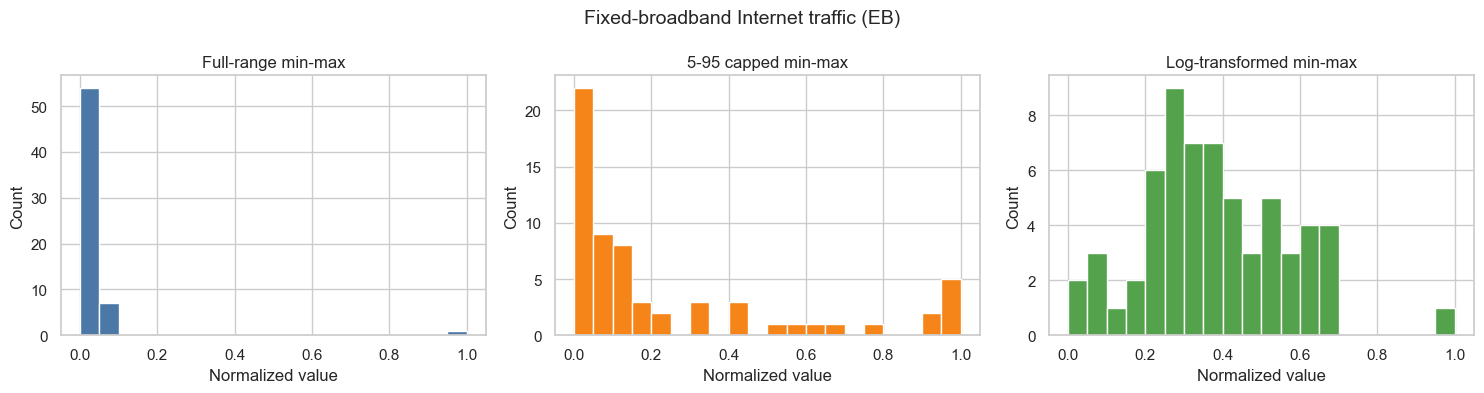

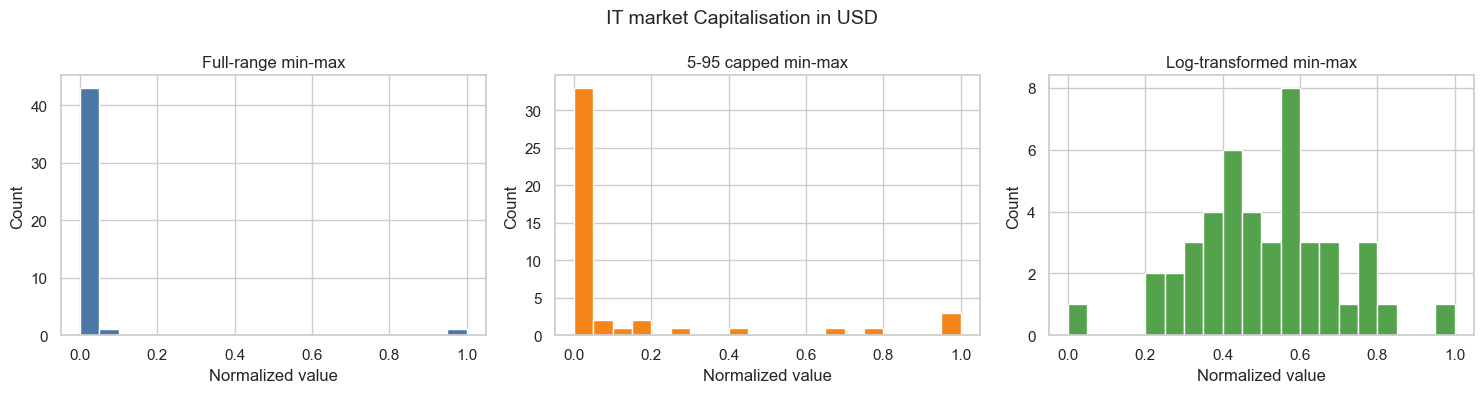

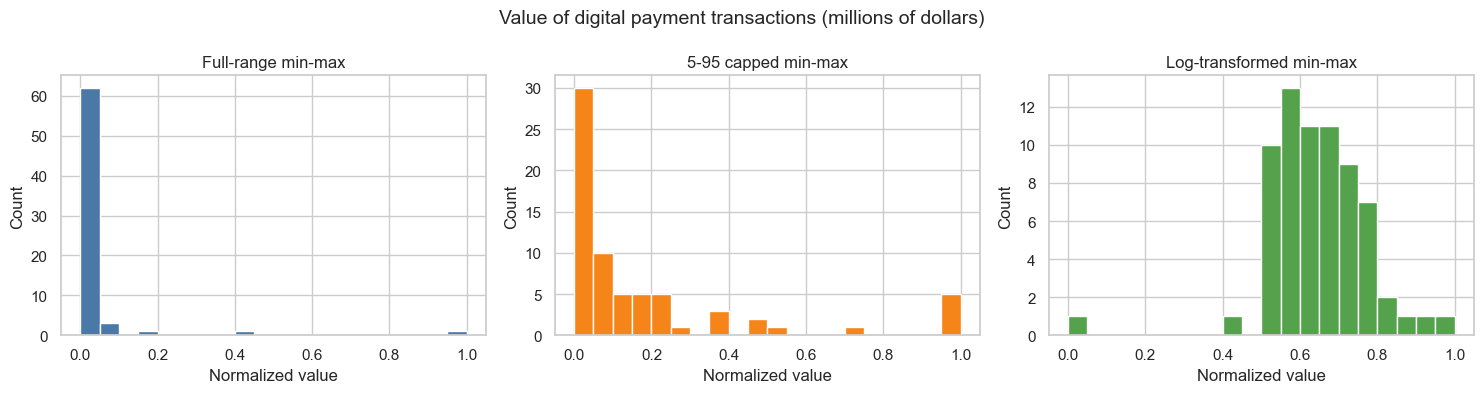

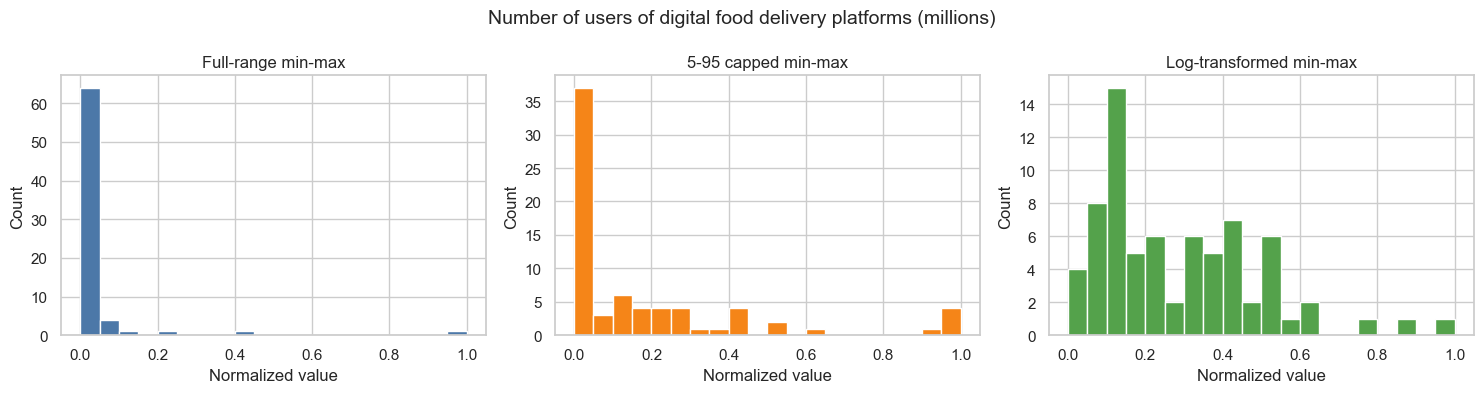

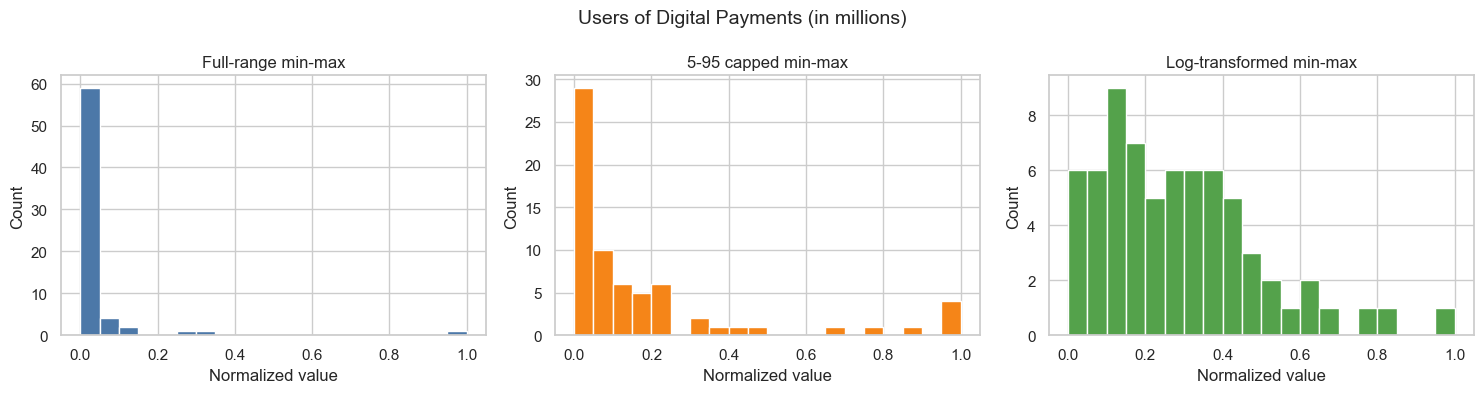

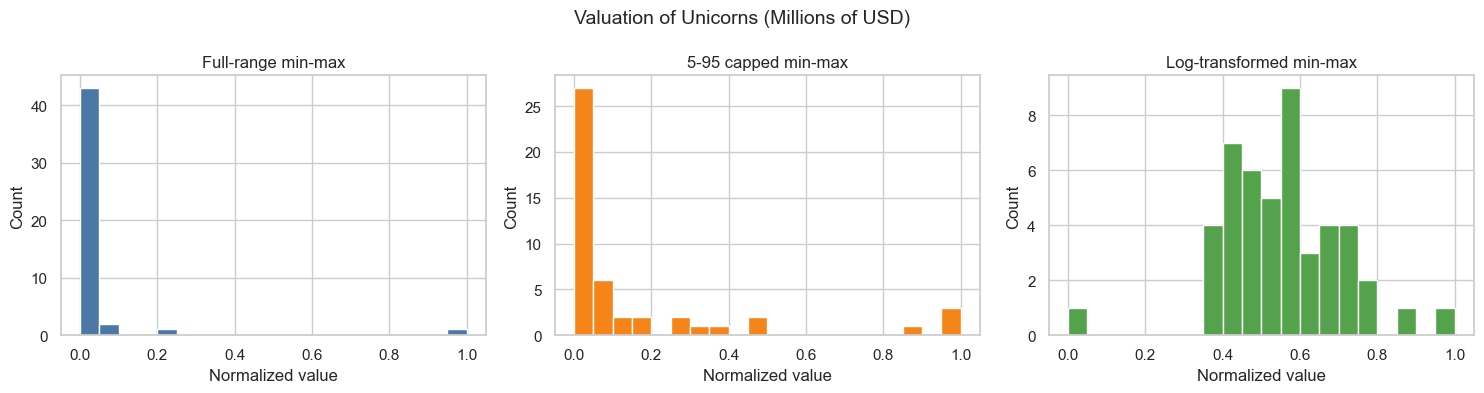

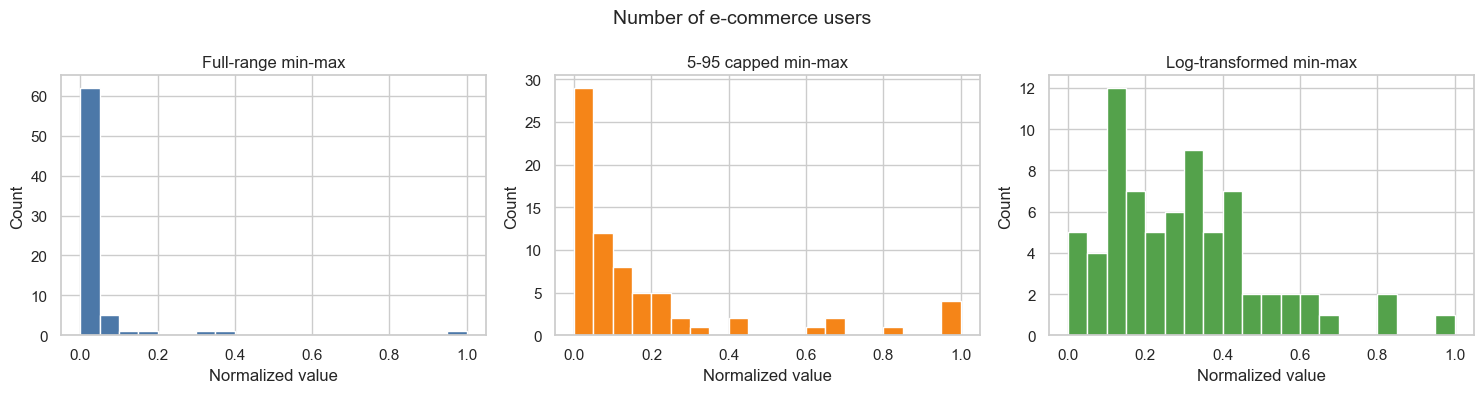

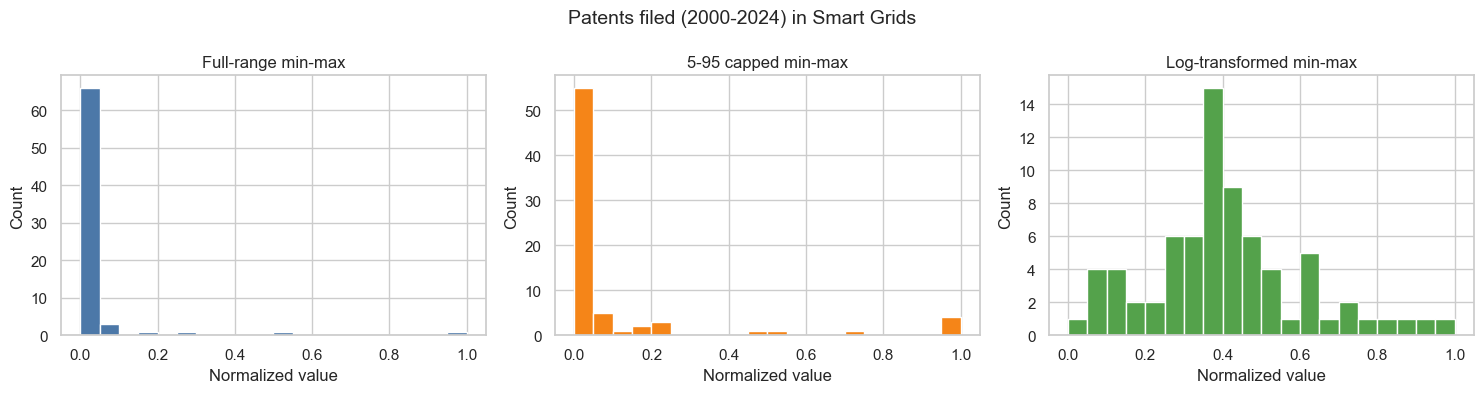

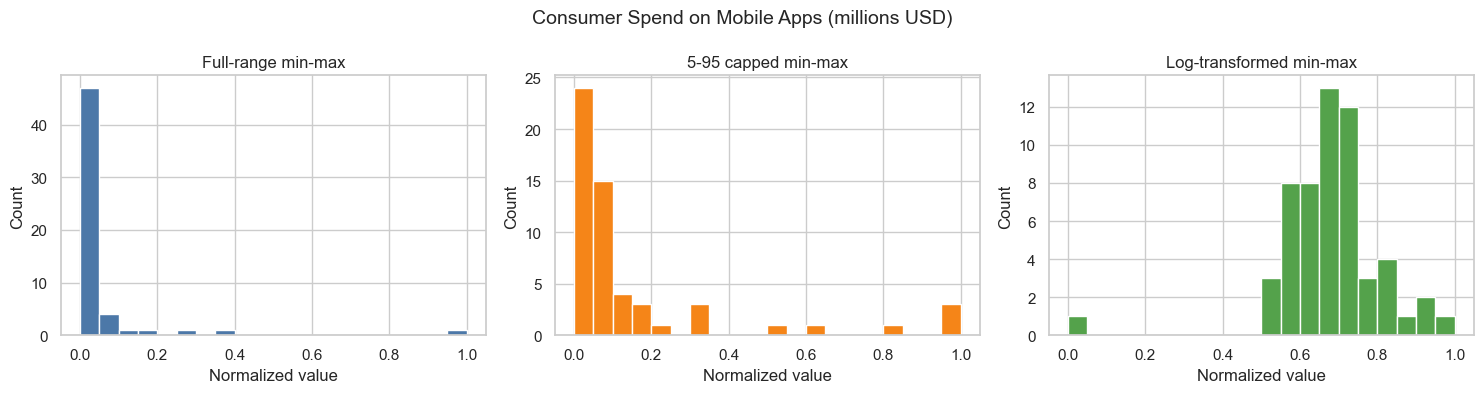

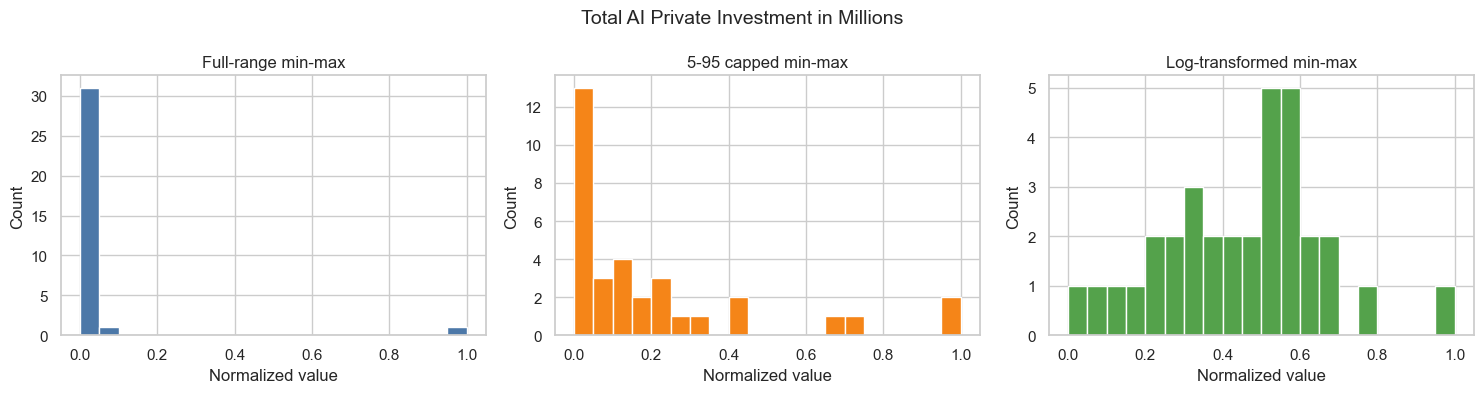

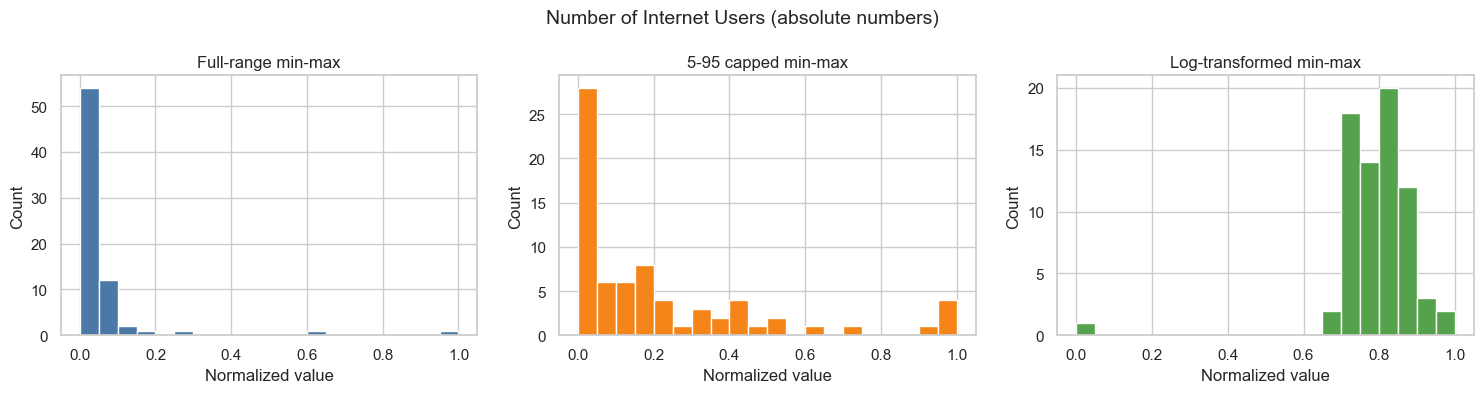

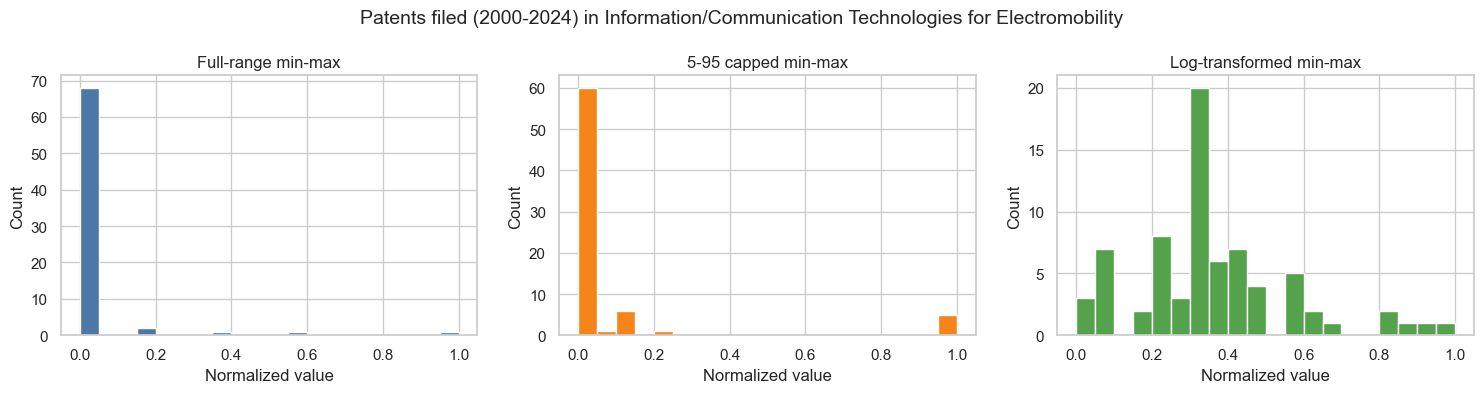

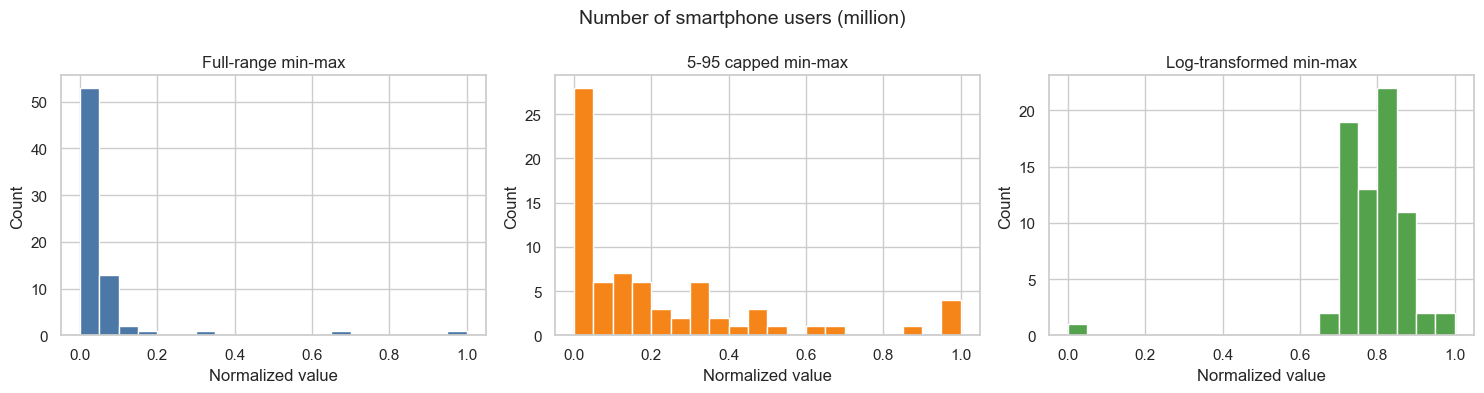

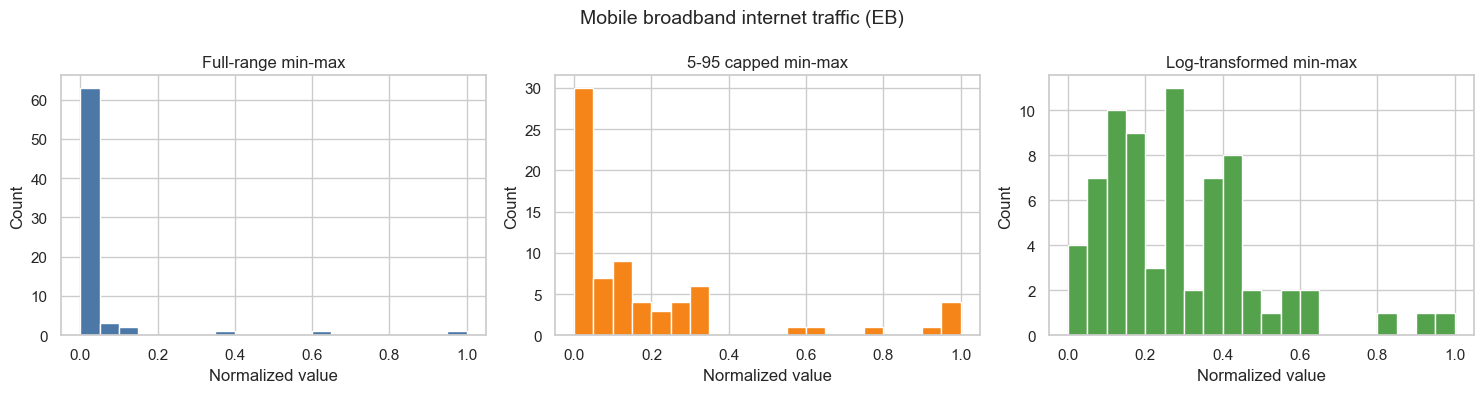

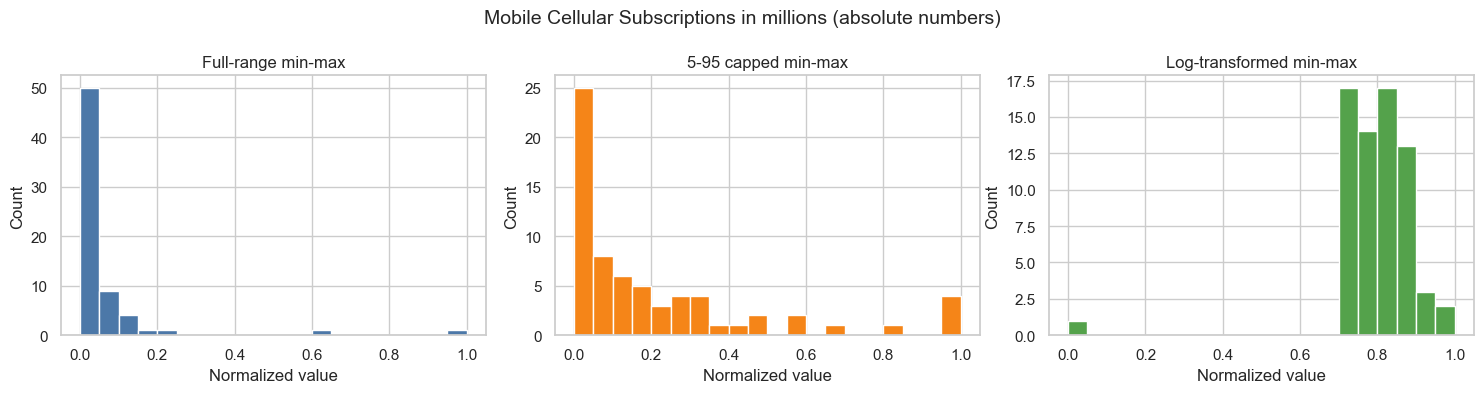

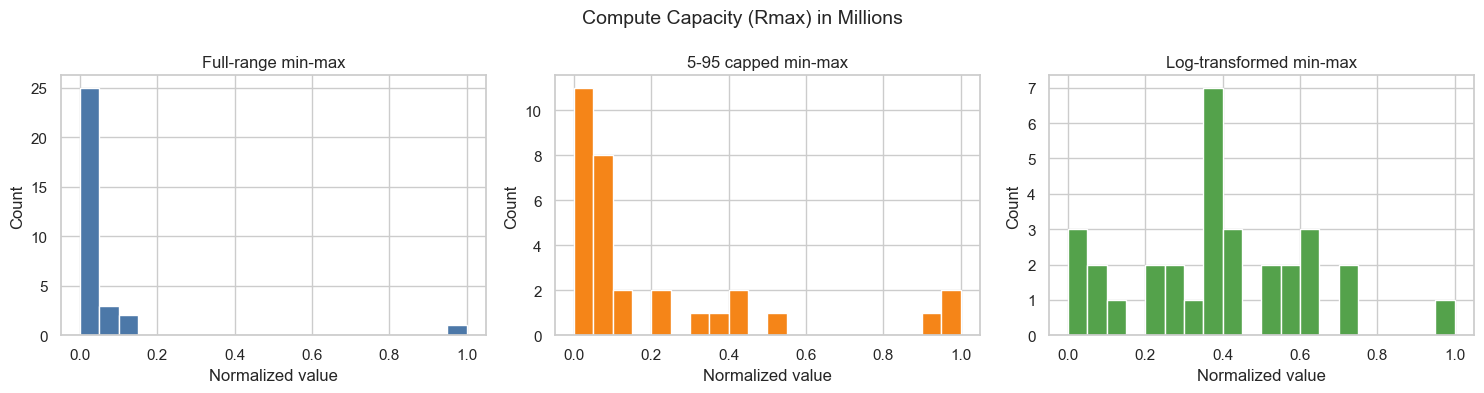

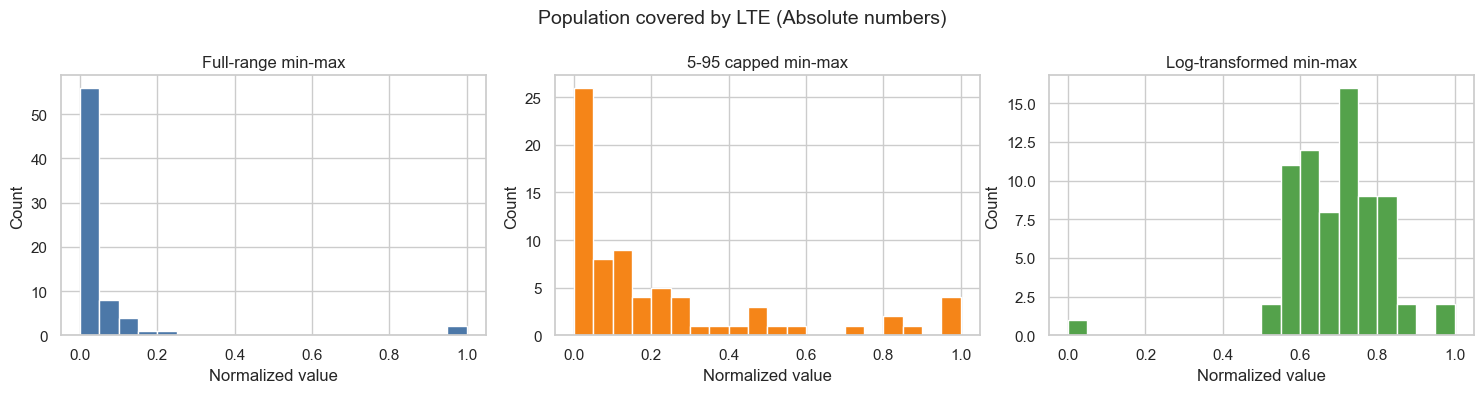

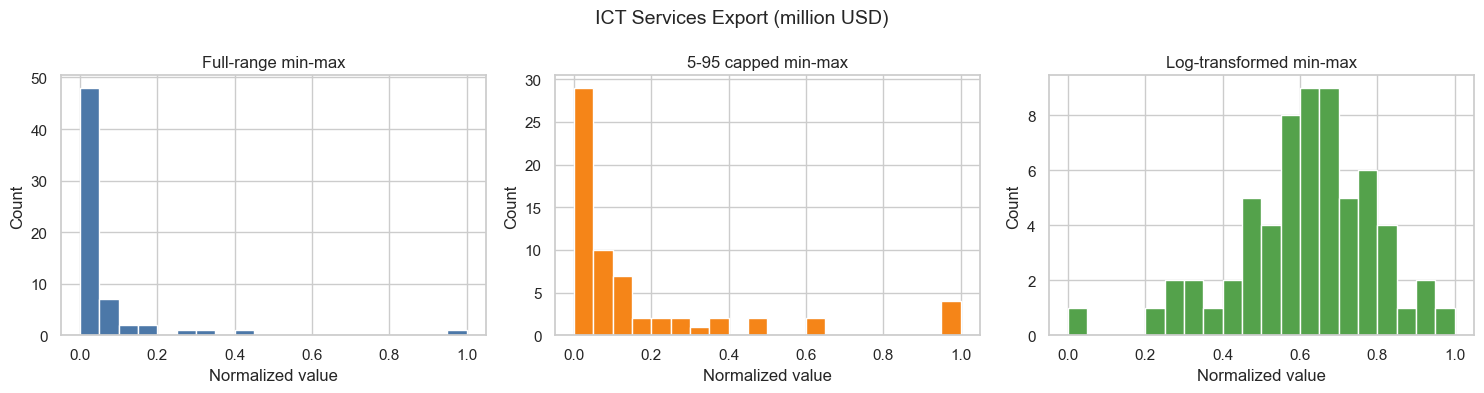

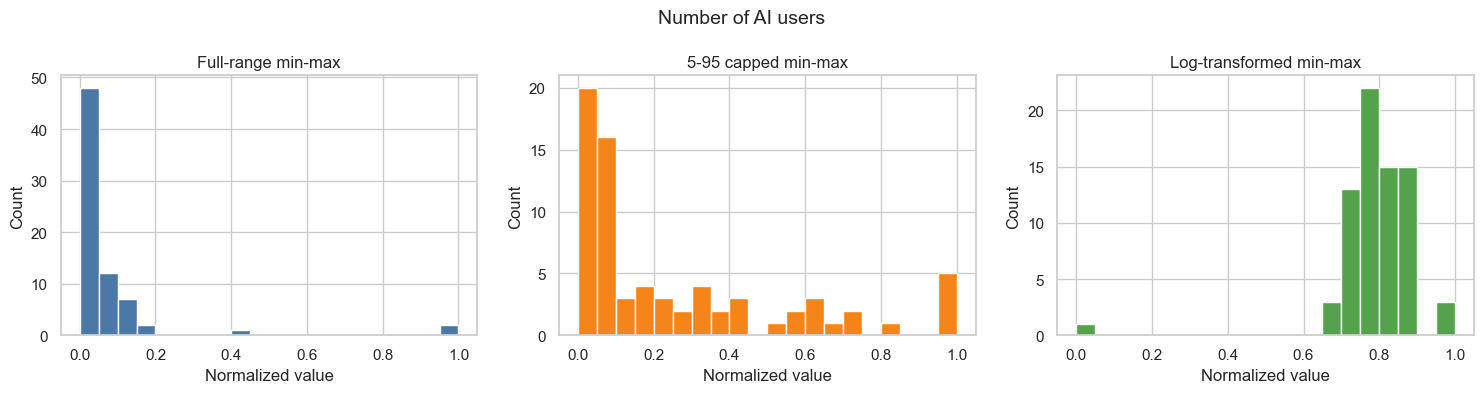

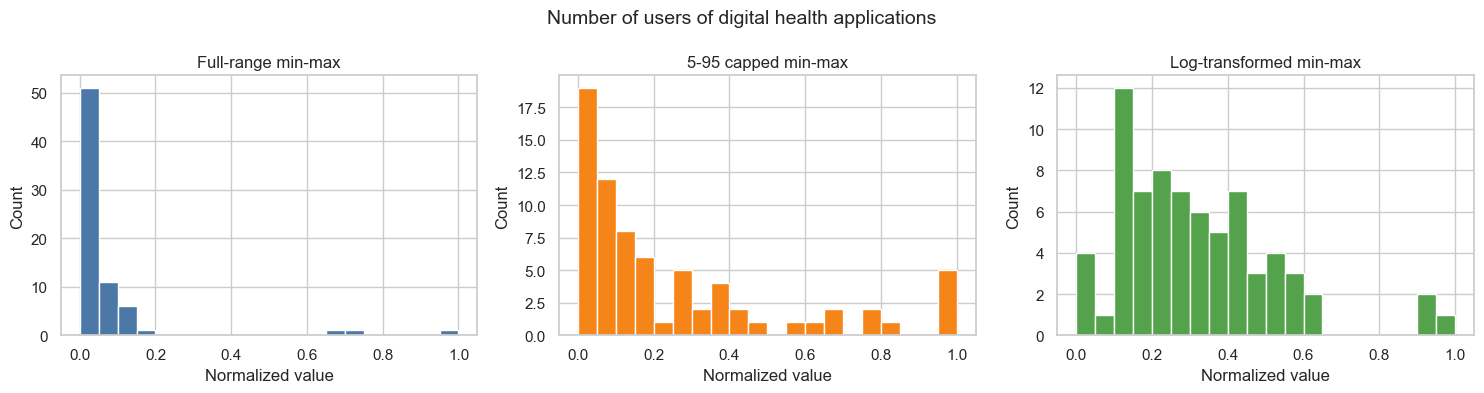

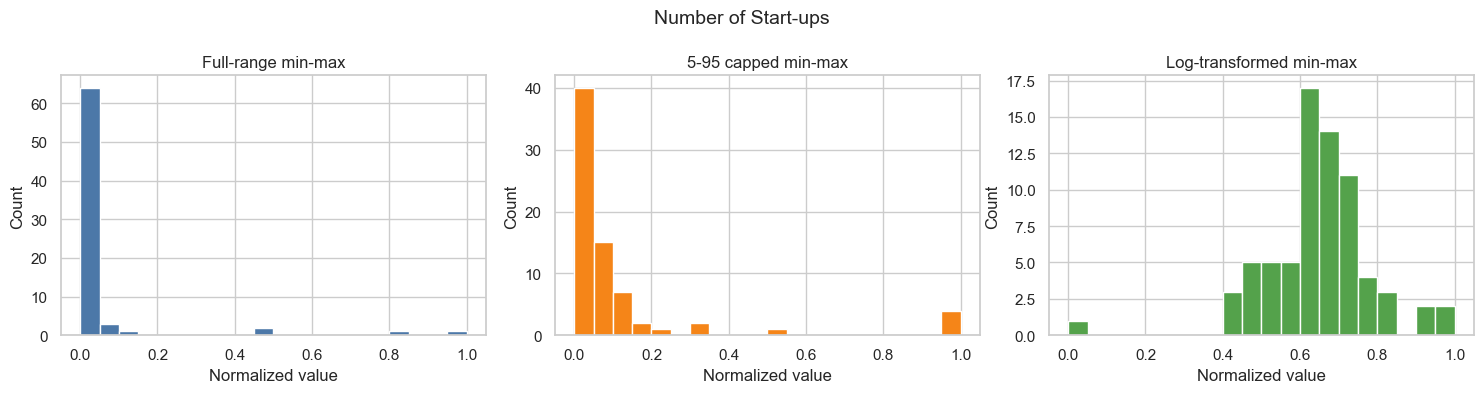

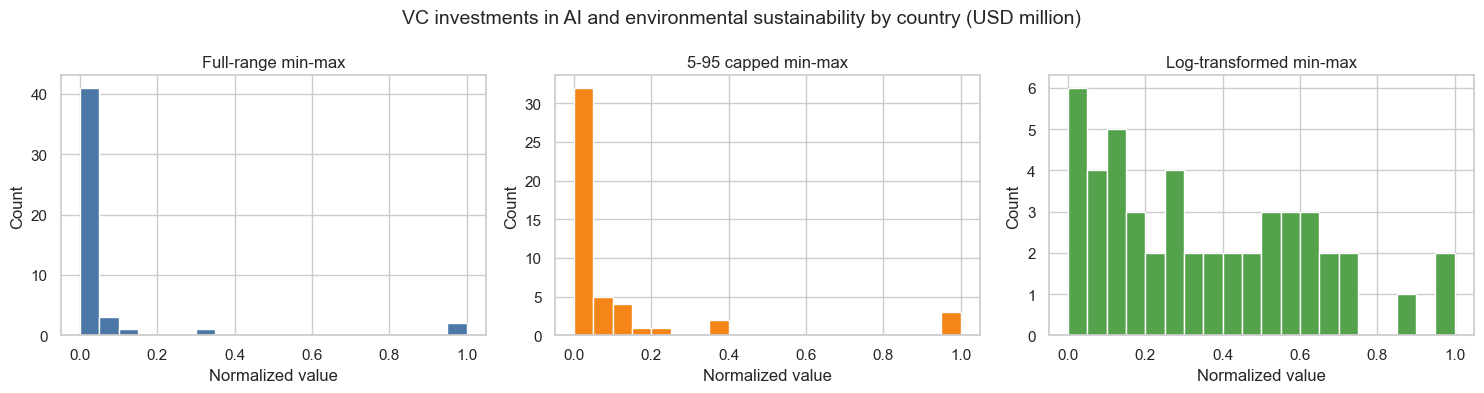

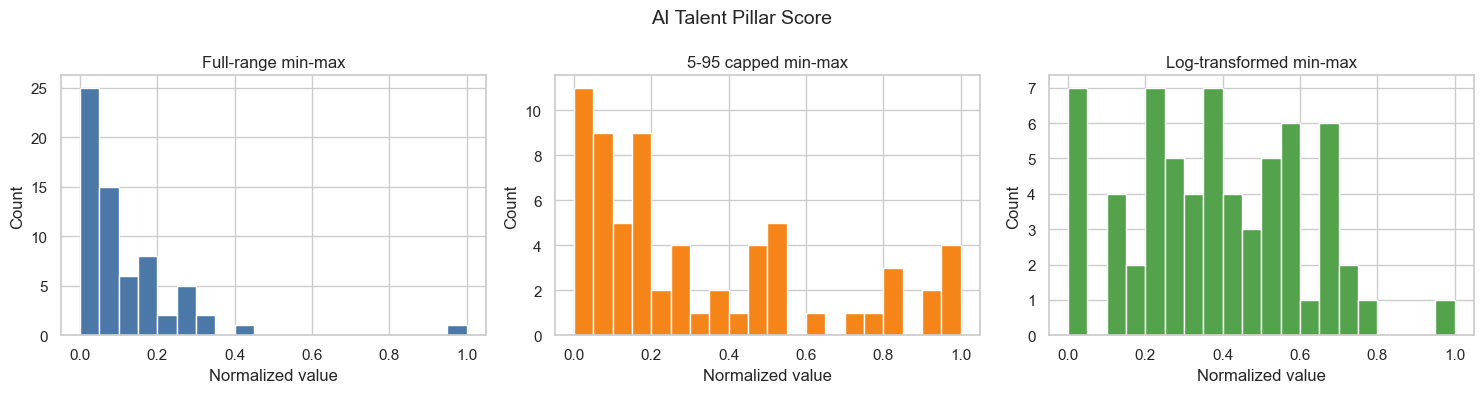

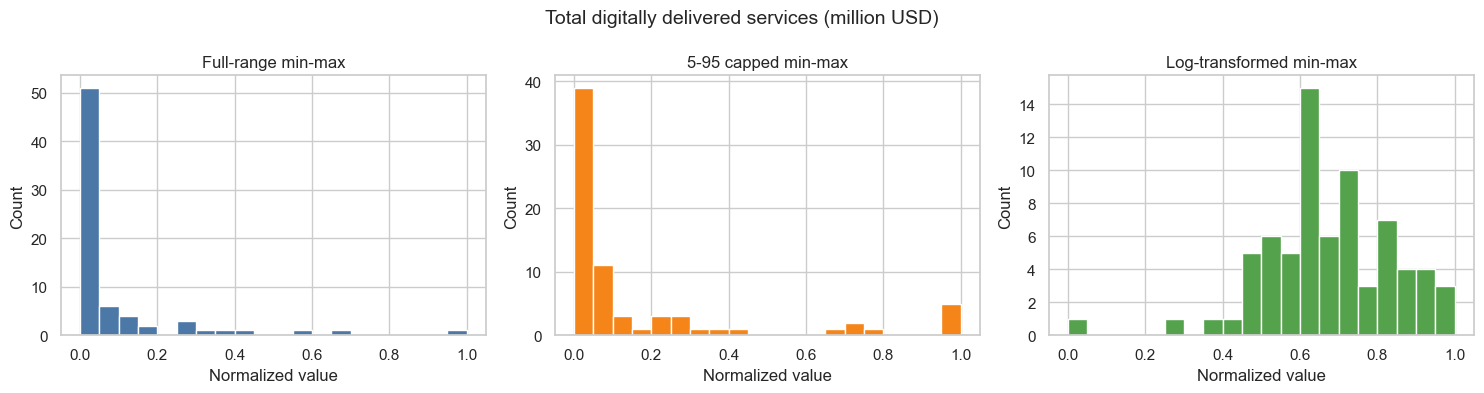

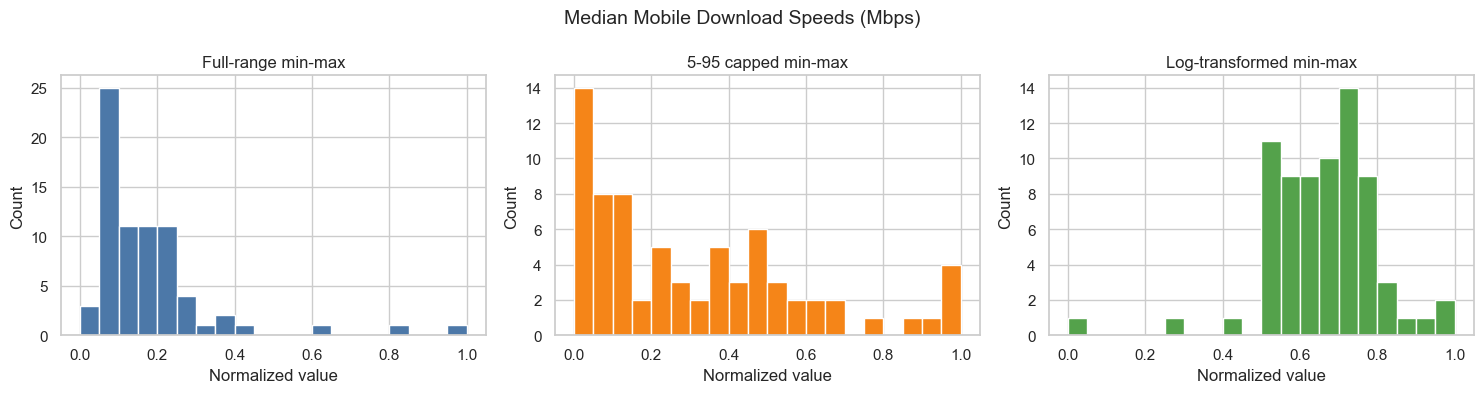

In [6]:
# Visual comparison for the first three skewed columns.
for col in columns_to_analyze:
    transformed = results[col]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(transformed["full_minmax"].dropna(), bins=20, color="#4C78A8")
    axes[0].set_title("Full-range min-max")
    axes[0].set_xlabel("Normalized value")
    axes[0].set_ylabel("Count")

    axes[1].hist(transformed["capped_5_95_minmax"].dropna(), bins=20, color="#F58518")
    axes[1].set_title("5-95 capped min-max")
    axes[1].set_xlabel("Normalized value")
    axes[1].set_ylabel("Count")

    axes[2].hist(transformed["log_minmax"].dropna(), bins=20, color="#54A24B")
    axes[2].set_title("Log-transformed min-max")
    axes[2].set_xlabel("Normalized value")
    axes[2].set_ylabel("Count")

    fig.suptitle(col, fontsize=14)
    plt.tight_layout()
    plt.show()

## Interpretation for the report

The three approaches answer slightly different questions:

- Full-range min-max is simple and easy to explain, but it can be overly influenced by a few very large observations.
- 5th to 95th percentile capped min-max is usually the most robust choice when the goal is to preserve relative ranking without letting a small number of outliers dominate the scale.
- Log-transformed min-max is helpful when the report wants to reflect percentage differences and compress the upper tail, but it is less intuitive for a general audience and can make the middle of the distribution look more compressed.

For most policy and comparative-report purposes, the capped 5-95 min-max approach is often the most useful because it keeps the scaling stable and interpretable while reducing the distortion caused by extreme values.

## Correlation analysis: comparing relationships across scaling choices

The next step is to test whether the relationships are robust, not just visually plausible. Because the dataset is strongly skewed, I will use both Pearson and Spearman correlations for each pair.

- Pearson checks whether the relationship is approximately linear.
- Spearman is often more useful for skewed data because it tests whether the variables move together in a monotonic way, which is often more realistic for policy and market indicators.
- I will compare the results using three transformed versions of each variable:
  - full-range min-max
  - 5th to 95th percentile capped min-max
  - log-transformed min-max

In [7]:
# Helper functions for pairwise correlation analysis across the three scaling choices.

def transform_series(series: pd.Series, method: str) -> pd.Series:
    if method == "full":
        return full_minmax(series)
    if method == "capped":
        return capped_minmax(series)
    if method == "log":
        return log_minmax(series)
    raise ValueError(f"Unknown method: {method}")


def compare_pair(x_col: str, y_col: str) -> pd.DataFrame:
    x = numeric_df[x_col]
    y = numeric_df[y_col]
    common_idx = x.dropna().index.intersection(y.dropna().index)
    x_common = x.loc[common_idx]
    y_common = y.loc[common_idx]

    rows = []
    for method in ["full", "capped", "log"]:
        x_scaled = transform_series(x_common, method).dropna()
        y_scaled = transform_series(y_common, method).dropna()
        common = x_scaled.index.intersection(y_scaled.index)
        x_scaled = x_scaled.loc[common]
        y_scaled = y_scaled.loc[common]

        rows.append({
            "pair": f"{x_col} | {y_col}",
            "method": method,
            "n": int(len(common)),
            "pearson": float(x_scaled.corr(y_scaled, method="pearson")),
            "spearman": float(x_scaled.corr(y_scaled, method="spearman")),
            "x_skew": float(x_common.skew()),
            "y_skew": float(y_common.skew()),
        })

    return pd.DataFrame(rows)


def run_theme(theme_name: str, description: str, pairs: list) -> None:
    print(f"\n{'=' * 80}\n{theme_name}\n{'=' * 80}")
    print(description)

    for x_col, y_col in pairs:
        result = compare_pair(x_col, y_col)
        print(f"\n{y_col} vs {x_col}")
        print(result[["method", "n", "pearson", "spearman"]].to_string(index=False))

        x = numeric_df[x_col]
        y = numeric_df[y_col]
        common_idx = x.dropna().index.intersection(y.dropna().index)
        x_common = x.loc[common_idx]
        y_common = y.loc[common_idx]

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        for ax, method in zip(axes, ["full", "capped", "log"]):
            x_scaled = transform_series(x_common, method).dropna()
            y_scaled = transform_series(y_common, method).dropna()
            common = x_scaled.index.intersection(y_scaled.index)
            x_scaled = x_scaled.loc[common]
            y_scaled = y_scaled.loc[common]
            ax.scatter(x_scaled, y_scaled, alpha=0.7, color="#4C78A8")
            ax.set_title(f"{method} min-max")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.25)

        fig.suptitle(f"{theme_name}: {x_col} vs {y_col}", fontsize=13)
        plt.tight_layout()
        plt.show()


Theme 1: Infrastructure vs adoption
This block looks at whether better infrastructure is associated with wider digital adoption, using both Pearson and Spearman correlations.

Number of Internet Users (absolute numbers) vs Median Mobile Download Speeds (Mbps)
method  n   pearson  spearman
  full 72  0.011249 -0.232798
capped 72 -0.053825 -0.238382
   log 72  0.328275 -0.232798


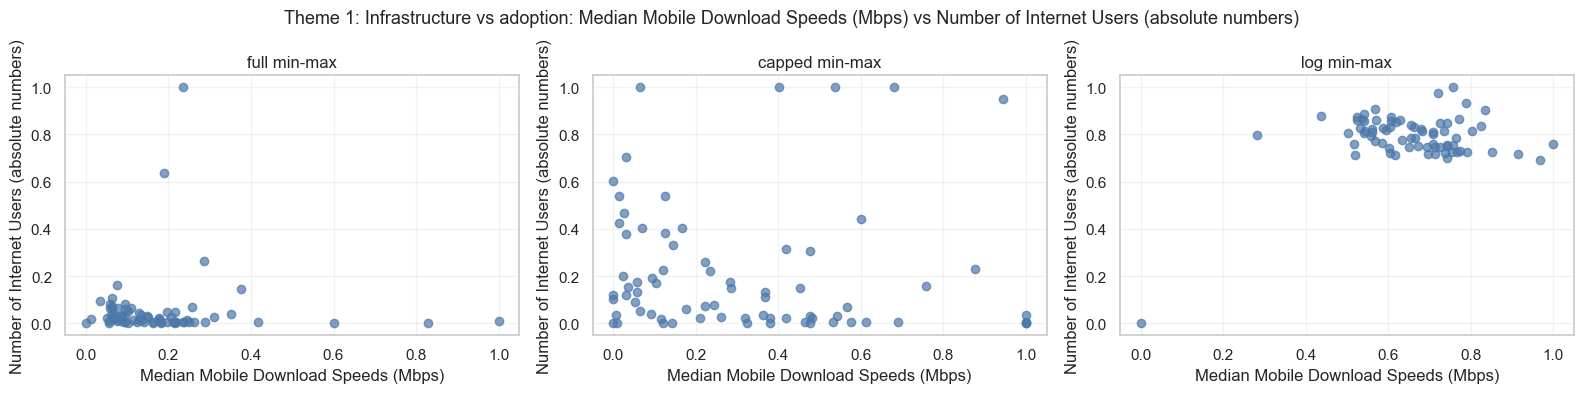


Number of smartphone users (million) vs Median Mobile Download Speeds (Mbps)
method  n   pearson  spearman
  full 72  0.018416 -0.177174
capped 72 -0.029855 -0.185378
   log 72  0.361379 -0.177174


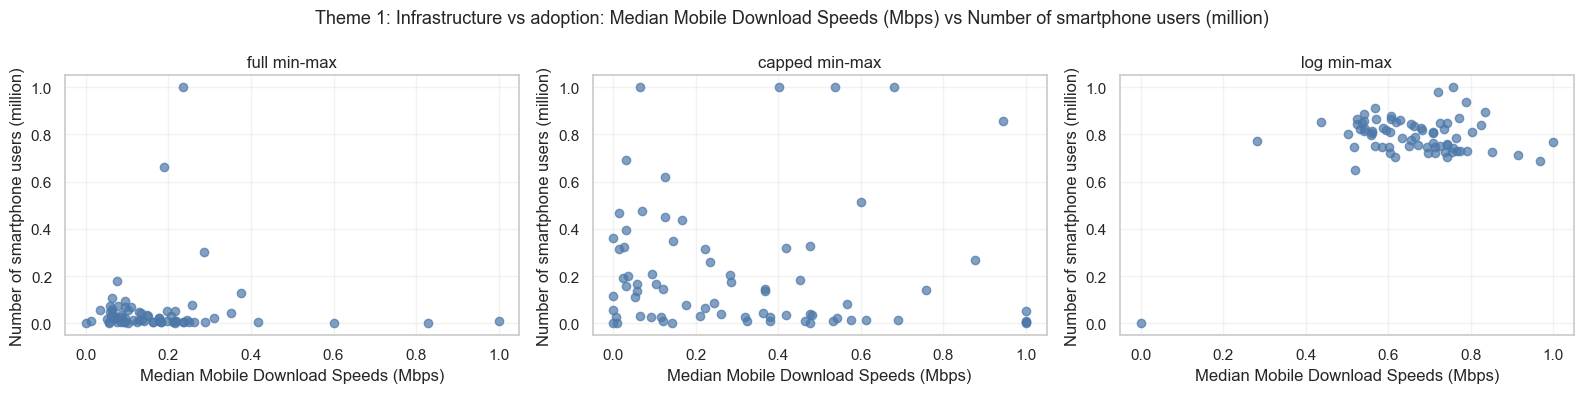


Mobile Cellular Subscriptions in millions (absolute numbers) vs Median Mobile Download Speeds (Mbps)
method  n   pearson  spearman
  full 67  0.028995 -0.232937
capped 67 -0.031875 -0.237272
   log 67  0.358422 -0.232937


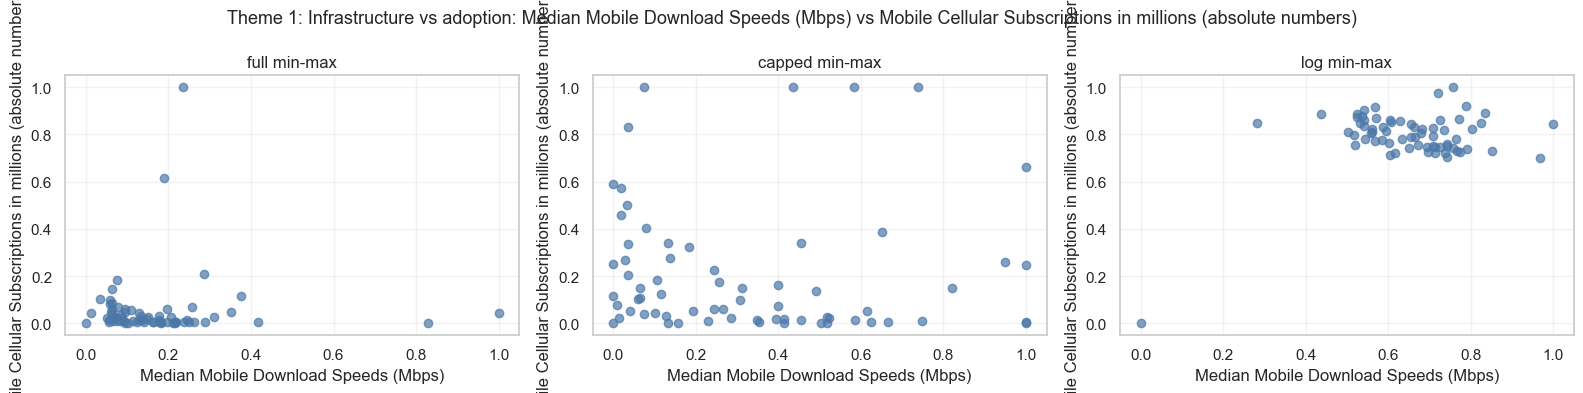


Population covered by LTE (Absolute numbers) vs Median Mobile Download Speeds (Mbps)
method  n   pearson  spearman
  full 72 -0.010128 -0.318890
capped 72 -0.132972 -0.323634
   log 72  0.113352 -0.318890


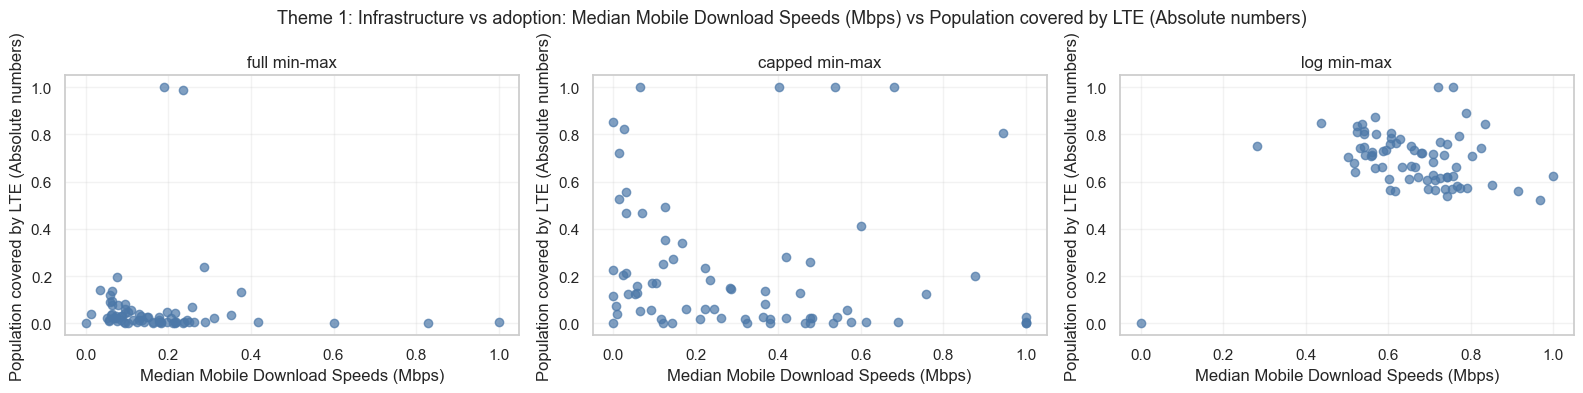


Fixed-broadband Internet traffic (EB) vs Median Mobile Download Speeds (Mbps)
method  n  pearson  spearman
  full 62 0.050184  0.202851
capped 62 0.142400  0.191437
   log 62 0.229290  0.202851


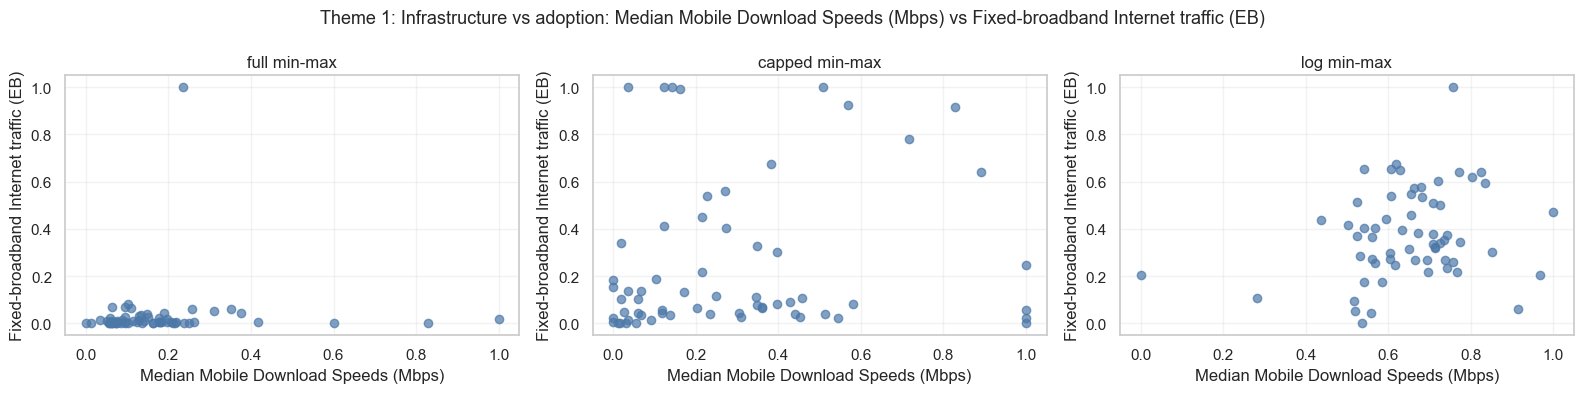

In [8]:
# Theme 1: infrastructure vs adoption
infrastructure_pairs = [
    ("Median Mobile Download Speeds (Mbps)", "Number of Internet Users (absolute numbers)"),
    ("Median Mobile Download Speeds (Mbps)", "Number of smartphone users (million)"),
    ("Median Mobile Download Speeds (Mbps)", "Mobile Cellular Subscriptions in millions (absolute numbers)"),
    ("Median Mobile Download Speeds (Mbps)", "Population covered by LTE (Absolute numbers)"),
    ("Median Mobile Download Speeds (Mbps)", "Fixed-broadband Internet traffic (EB)"),
]
run_theme(
    "Theme 1: Infrastructure vs adoption",
    "This block looks at whether better infrastructure is associated with wider digital adoption, using both Pearson and Spearman correlations.",
    infrastructure_pairs,
)


Theme 2: Affordability vs adoption
This block tests whether lower device and access costs are linked to higher adoption and stronger infrastructure performance.

Number of smartphone users (million) vs Price of cheapest smartphone (PPP$)
method  n  pearson  spearman
  full 65 0.278086  0.325371
capped 65 0.232620  0.316680
   log 65 0.743379  0.325371


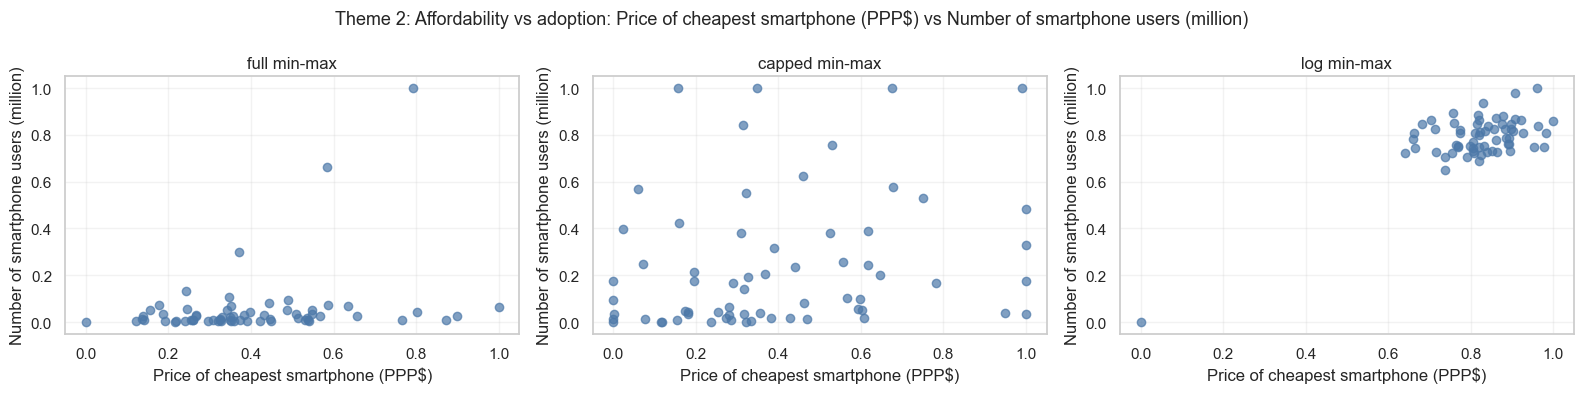


Number of Internet Users (absolute numbers) vs Price of cheapest smartphone (PPP$)
method  n  pearson  spearman
  full 65 0.276317  0.334444
capped 65 0.219534  0.326566
   log 65 0.743803  0.334444


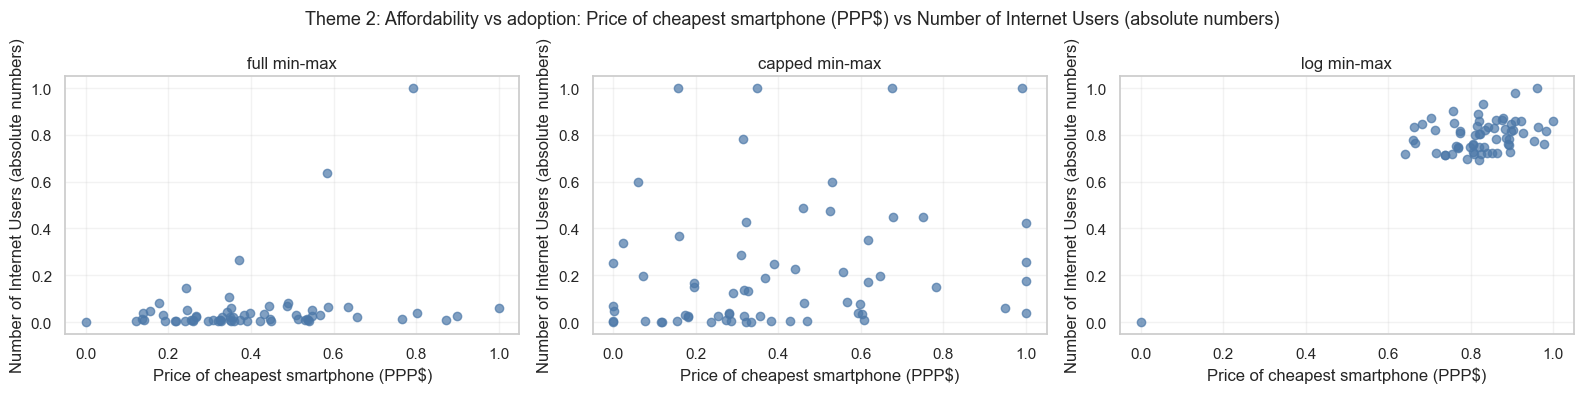


Median Mobile Download Speeds (Mbps) vs Price of cheapest smartphone (PPP$)
method  n  pearson  spearman
  full 65 0.000250  0.031607
capped 65 0.046044  0.032922
   log 65 0.465165  0.031607


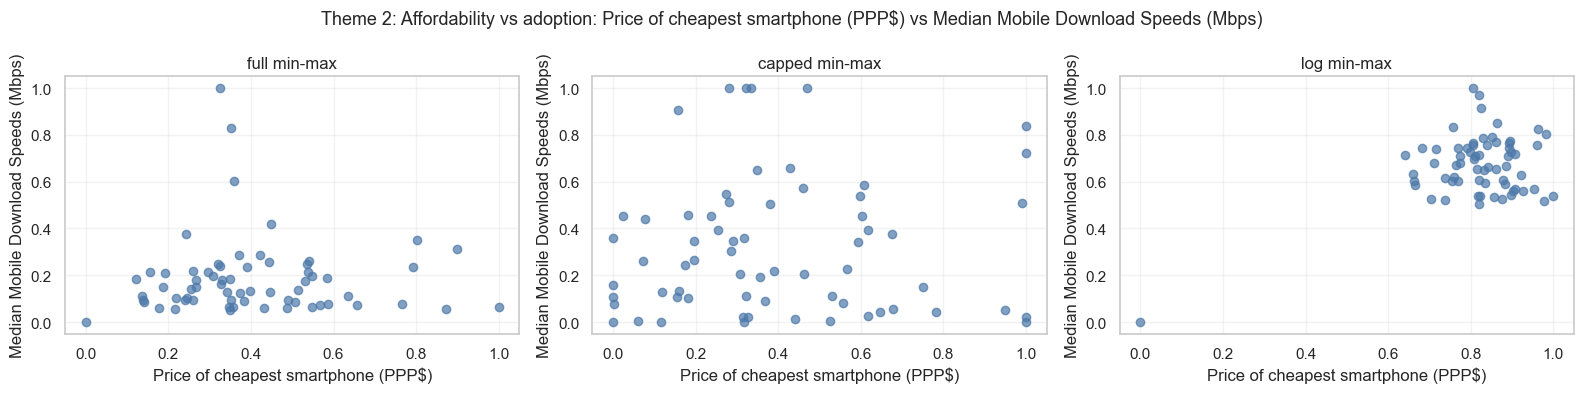


Number of smartphone users (million) vs Price of mobile data and voice basket (HC) (PPP)
method  n   pearson  spearman
  full 72 -0.105938 -0.148223
capped 72 -0.164275 -0.151306
   log 72  0.358715 -0.148223


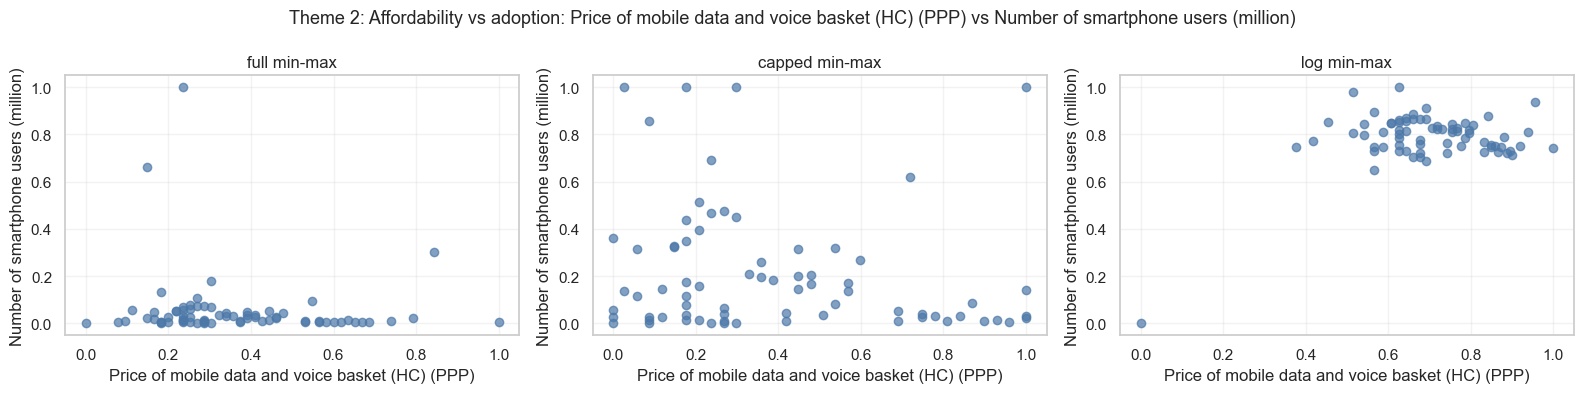


Number of Internet Users (absolute numbers) vs Price of mobile data and voice basket (HC) (PPP)
method  n   pearson  spearman
  full 72 -0.122316 -0.153569
capped 72 -0.194020 -0.157000
   log 72  0.341932 -0.153569


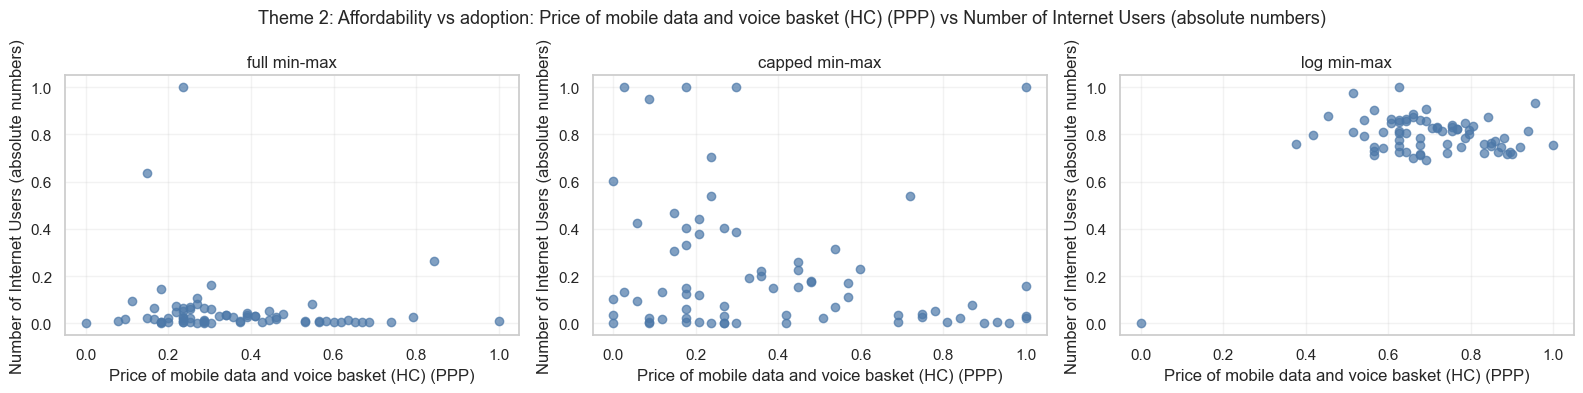


Median Mobile Download Speeds (Mbps) vs Price of mobile data and voice basket (HC) (PPP)
method  n  pearson  spearman
  full 72 0.306779  0.381613
capped 72 0.360450  0.380343
   log 72 0.602168  0.381613


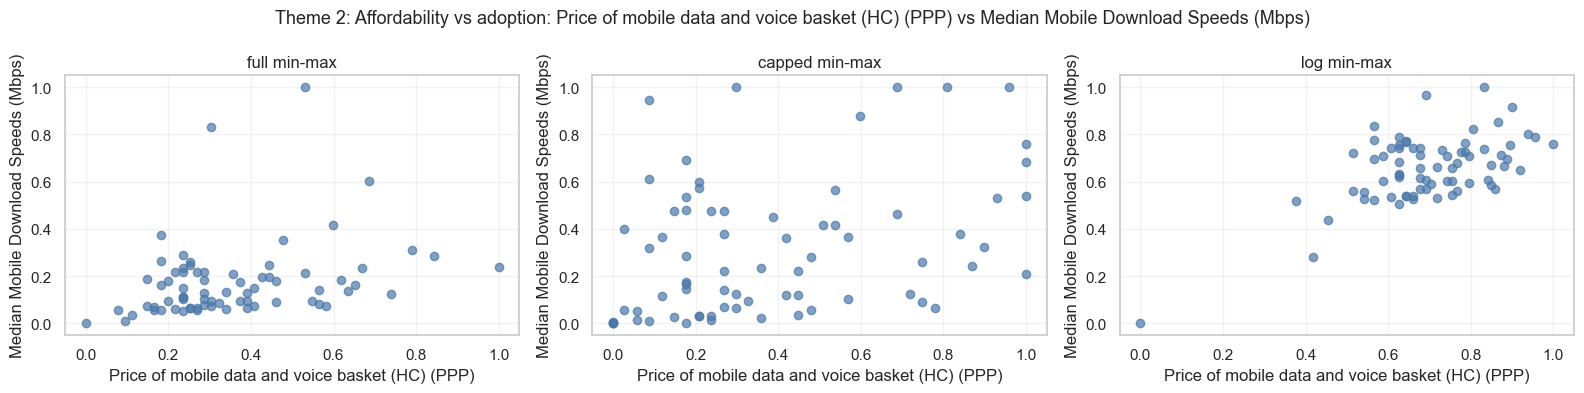

In [9]:
# Theme 2: affordability vs adoption
affordability_pairs = [
    ("Price of cheapest smartphone (PPP$)", "Number of smartphone users (million)"),
    ("Price of cheapest smartphone (PPP$)", "Number of Internet Users (absolute numbers)"),
    ("Price of cheapest smartphone (PPP$)", "Median Mobile Download Speeds (Mbps)"),
    ("Price of mobile data and voice basket (HC) (PPP)", "Number of smartphone users (million)"),
    ("Price of mobile data and voice basket (HC) (PPP)", "Number of Internet Users (absolute numbers)"),
    ("Price of mobile data and voice basket (HC) (PPP)", "Median Mobile Download Speeds (Mbps)"),
]
run_theme(
    "Theme 2: Affordability vs adoption",
    "This block tests whether lower device and access costs are linked to higher adoption and stronger infrastructure performance.",
    affordability_pairs,
)


Theme 3: Digital economy activity
This block explores whether digital-payment adoption tracks other consumer-facing digital activity such as e-commerce and mobile-app spend.

Value of digital payment transactions (millions of dollars) vs Users of Digital Payments (in millions)
method  n  pearson  spearman
  full 68 0.968838  0.866626
capped 68 0.864089  0.866031
   log 68 0.785320  0.866626


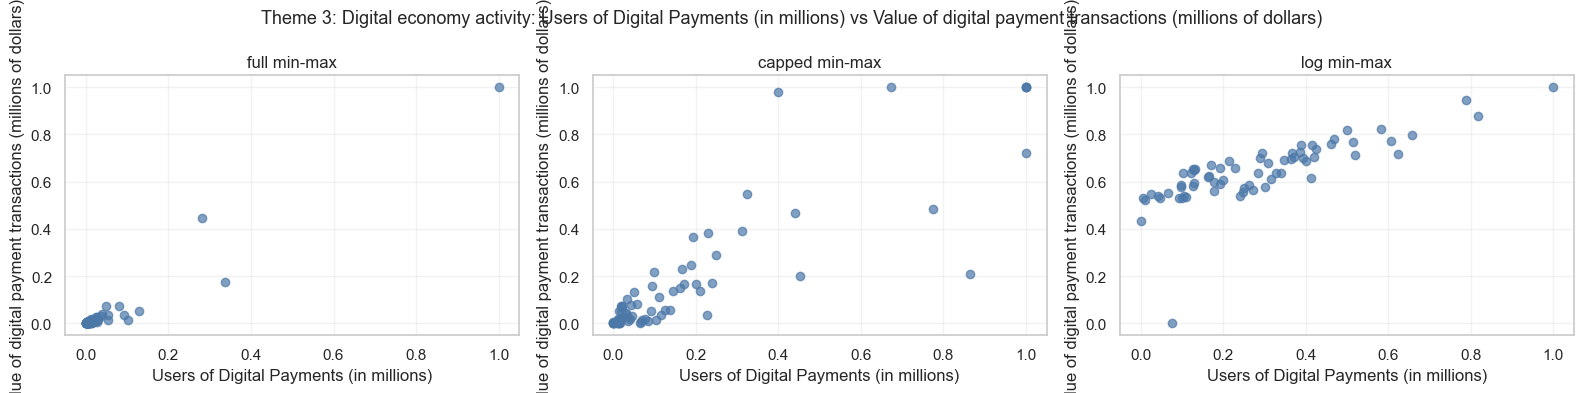


Number of e-commerce users vs Users of Digital Payments (in millions)
method  n  pearson  spearman
  full 68 0.998771  0.997385
capped 68 0.993607  0.997384
   log 68 0.998015  0.997385


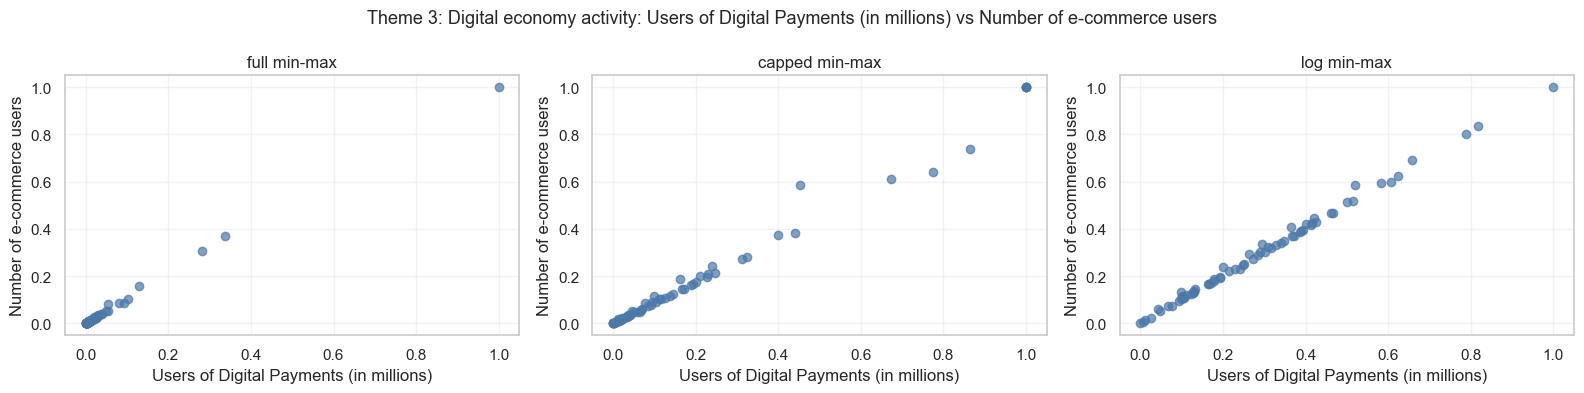


Number of users of digital food delivery platforms (millions) vs Users of Digital Payments (in millions)
method  n  pearson  spearman
  full 68 0.992541  0.950520
capped 68 0.922177  0.950358
   log 68 0.955760  0.950520


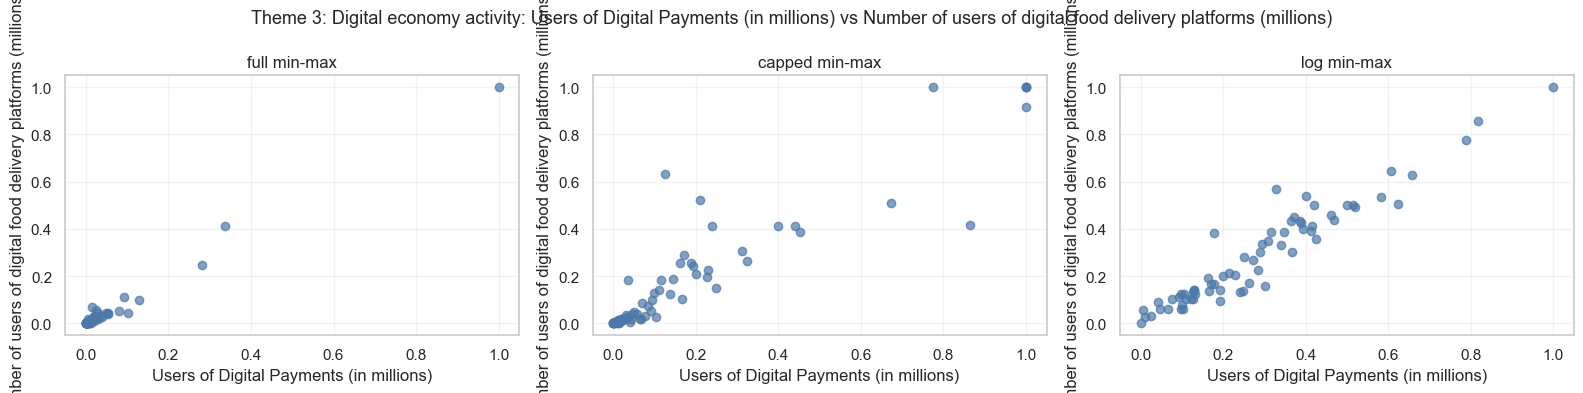


Consumer Spend on Mobile Apps (millions USD) vs Users of Digital Payments (in millions)
method  n  pearson  spearman
  full 54 0.426437  0.643530
capped 54 0.625874  0.642963
   log 54 0.576389  0.643530


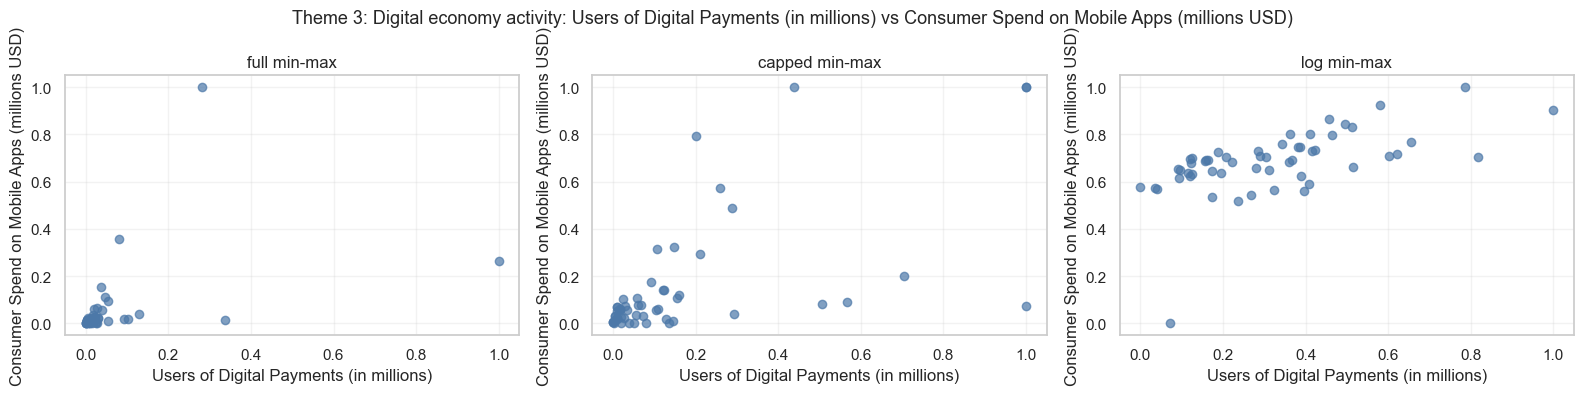

In [10]:
# Theme 3: digital economy activity
platform_pairs = [
    ("Users of Digital Payments (in millions)", "Value of digital payment transactions (millions of dollars)"),
    ("Users of Digital Payments (in millions)", "Number of e-commerce users"),
    ("Users of Digital Payments (in millions)", "Number of users of digital food delivery platforms (millions)"),
    ("Users of Digital Payments (in millions)", "Consumer Spend on Mobile Apps (millions USD)"),
]
run_theme(
    "Theme 3: Digital economy activity",
    "This block explores whether digital-payment adoption tracks other consumer-facing digital activity such as e-commerce and mobile-app spend.",
    platform_pairs,
)


Theme 4: AI ecosystem
This block asks whether AI adoption is more closely linked to investment, talent, compute capacity, or research output.

Total AI Private Investment in Millions vs Number of AI users
method  n  pearson  spearman
  full 33 0.285046  0.549465
capped 33 0.589394  0.546974
   log 33 0.556627  0.549465


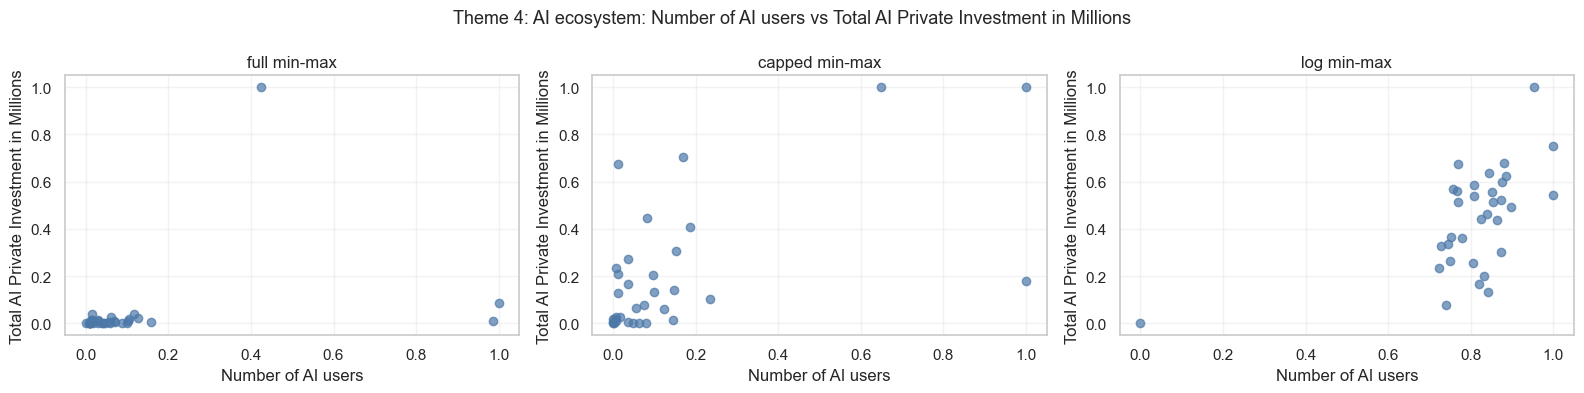


AI Talent Pillar Score vs Number of AI users
method  n  pearson  spearman
  full 65 0.476701  0.209125
capped 65 0.367167  0.206708
   log 65 0.318396  0.209125


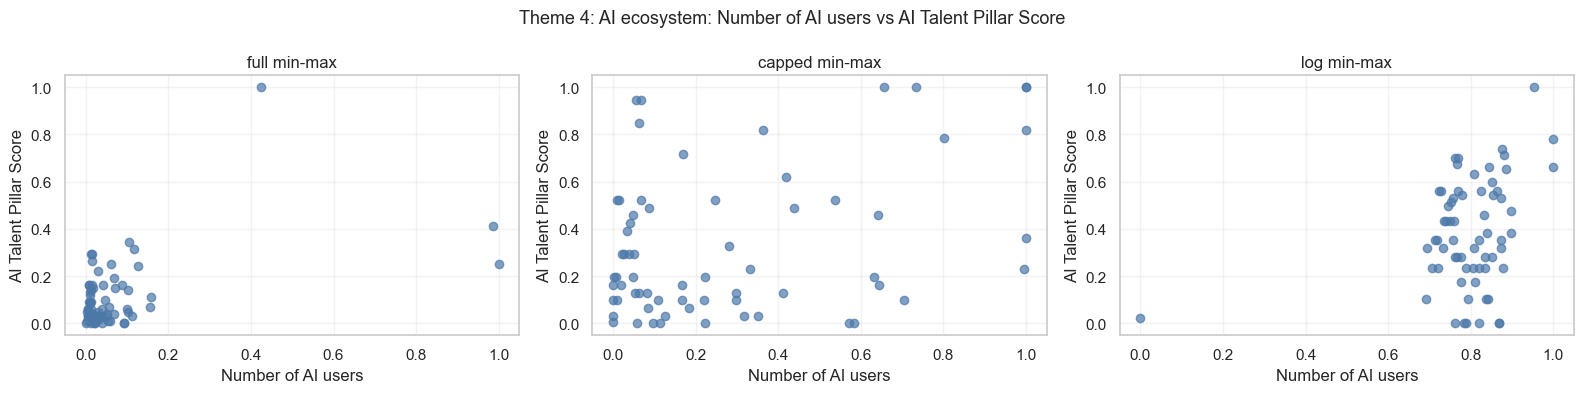


Compute Capacity (Rmax) in Millions vs Number of AI users
method  n  pearson  spearman
  full 31 0.237329  0.509227
capped 31 0.241915  0.502572
   log 31 0.463347  0.509227


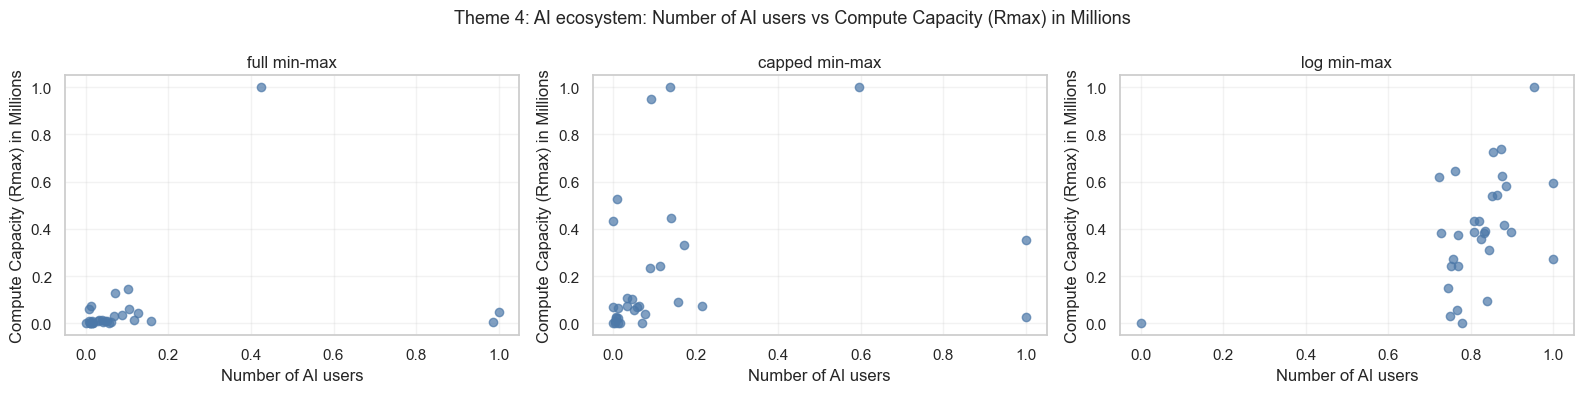


Open Data Score vs Number of AI users
method  n   pearson  spearman
  full 72 -0.173338 -0.049261
capped 72 -0.103877 -0.052879
   log 72  0.698311 -0.049261


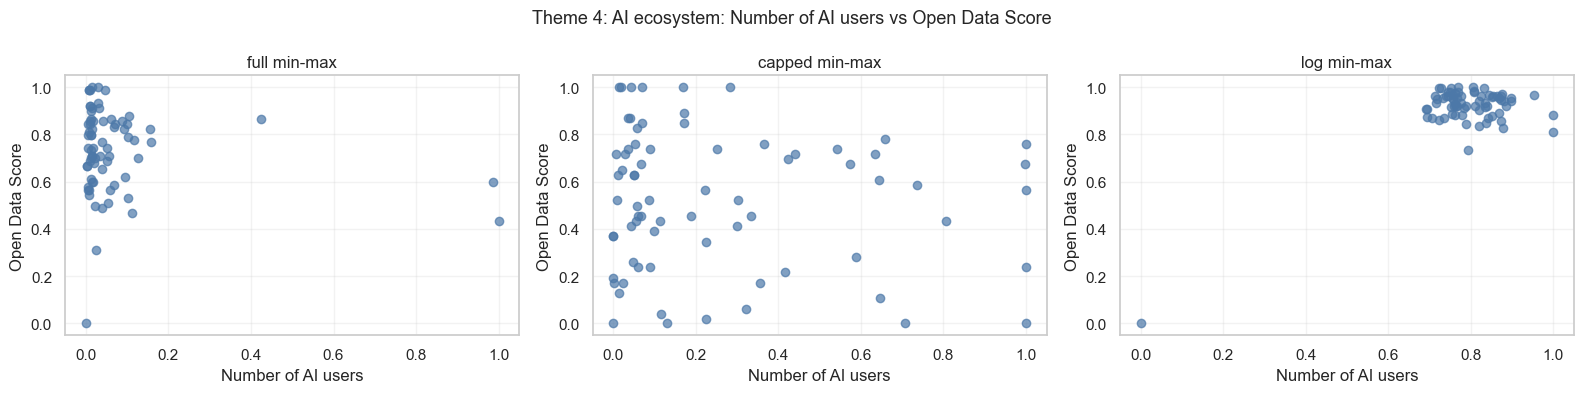


Patents filed (2000-2024) in Information/Communication Technologies for Electromobility vs Number of AI users
method  n  pearson  spearman
  full 72 0.673682  0.479401
capped 72 0.500178  0.472386
   log 72 0.415029  0.479401


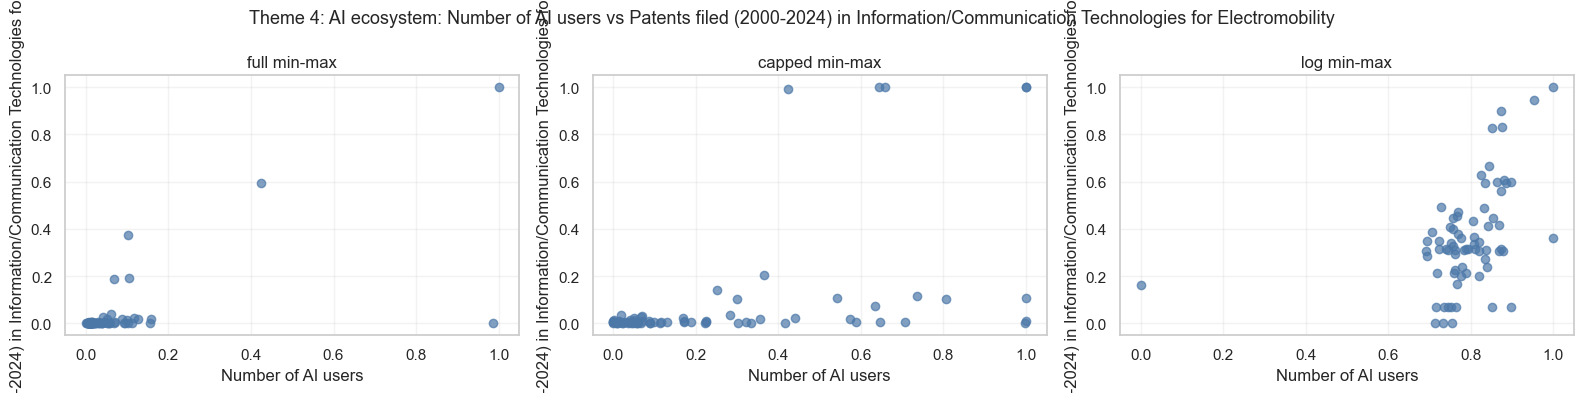

In [11]:
# Theme 4: AI ecosystem
ai_pairs = [
    ("Number of AI users", "Total AI Private Investment in Millions"),
    ("Number of AI users", "AI Talent Pillar Score"),
    ("Number of AI users", "Compute Capacity (Rmax) in Millions"),
    ("Number of AI users", "Open Data Score"),
    ("Number of AI users", "Patents filed (2000-2024) in Information/Communication Technologies for Electromobility"),
]
run_theme(
    "Theme 4: AI ecosystem",
    "This block asks whether AI adoption is more closely linked to investment, talent, compute capacity, or research output.",
    ai_pairs,
)


Theme 5: Startup and innovation scale
This block tests whether startup proliferation and unicorn valuation are linked to broader digital-sector capital and market depth.

VC investments in AI and environmental sustainability by country (USD million) vs Number of Start-ups
method  n  pearson  spearman
  full 47 0.855105  0.308143
capped 47 0.516101  0.301751
   log 47 0.338657  0.308143


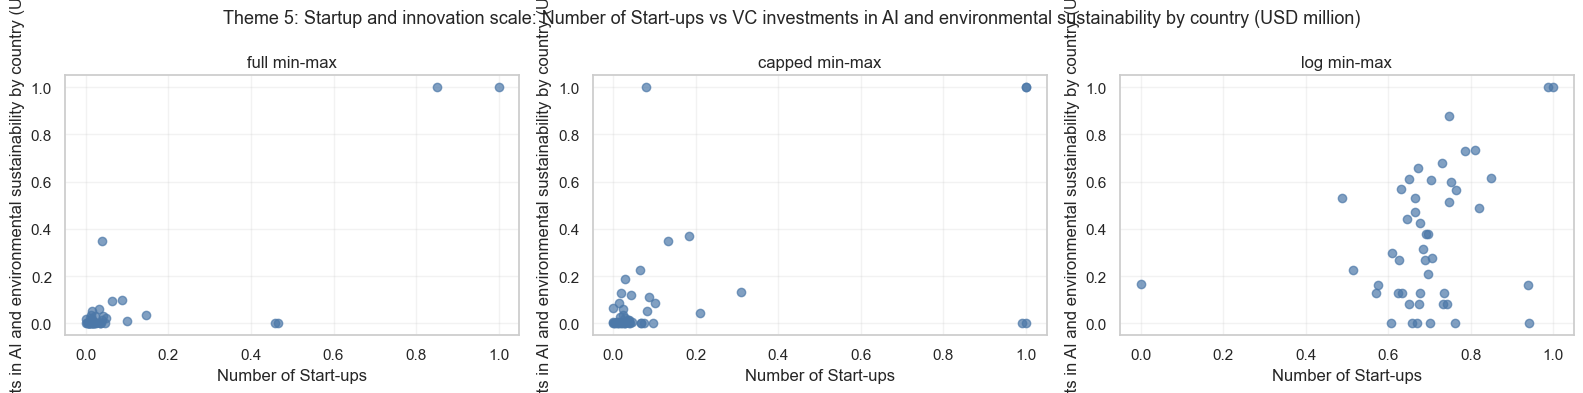


ICT Services Export (million USD) vs Number of Start-ups
method  n  pearson  spearman
  full 63 0.334263  0.714798
capped 63 0.695464  0.716763
   log 63 0.770845  0.714798


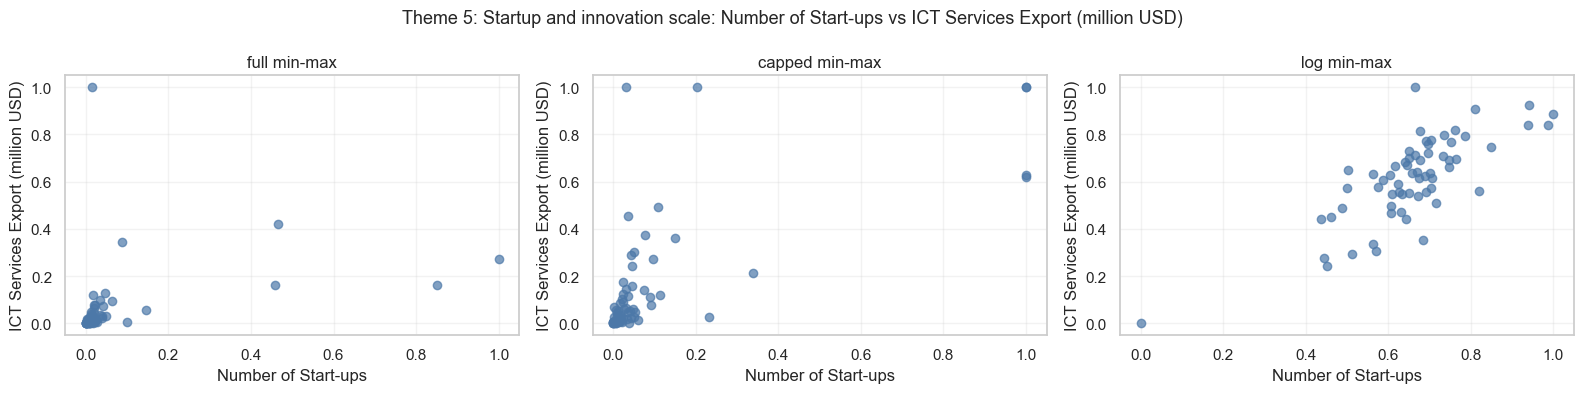


IT market Capitalisation in USD vs Number of Start-ups
method  n  pearson  spearman
  full 45 0.679270  0.740184
capped 45 0.378769  0.733456
   log 45 0.750794  0.740184


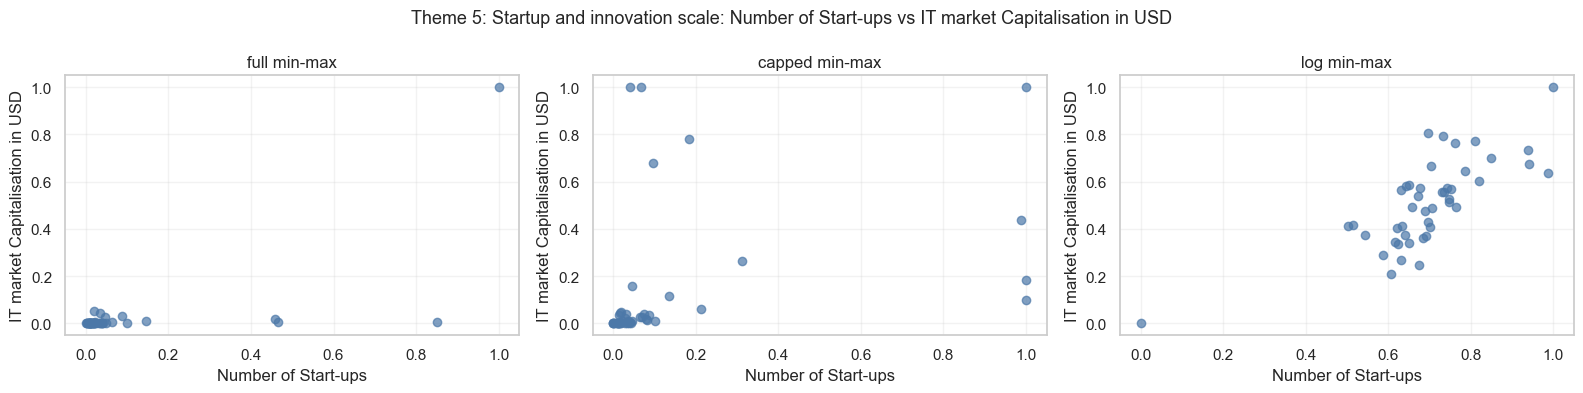


VC investments in AI and environmental sustainability by country (USD million) vs Valuation of Unicorns (Millions of USD)
method  n  pearson  spearman
  full 40 0.701400  0.310217
capped 40 0.583348  0.308160
   log 40 0.392151  0.310217


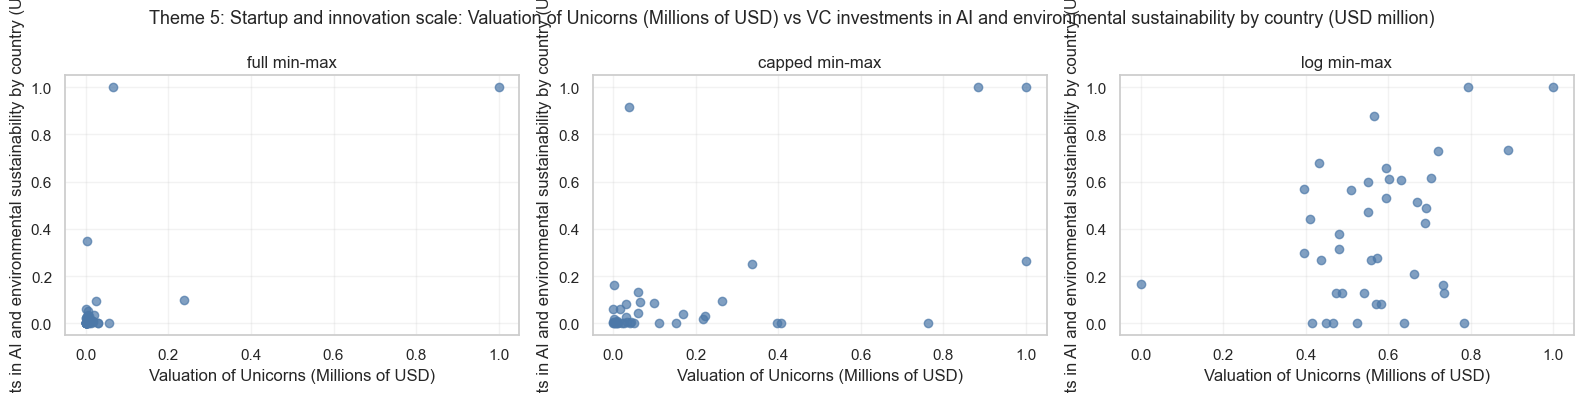


ICT Services Export (million USD) vs Valuation of Unicorns (Millions of USD)
method  n  pearson  spearman
  full 44 0.253571  0.767658
capped 44 0.780500  0.765677
   log 44 0.789264  0.767658


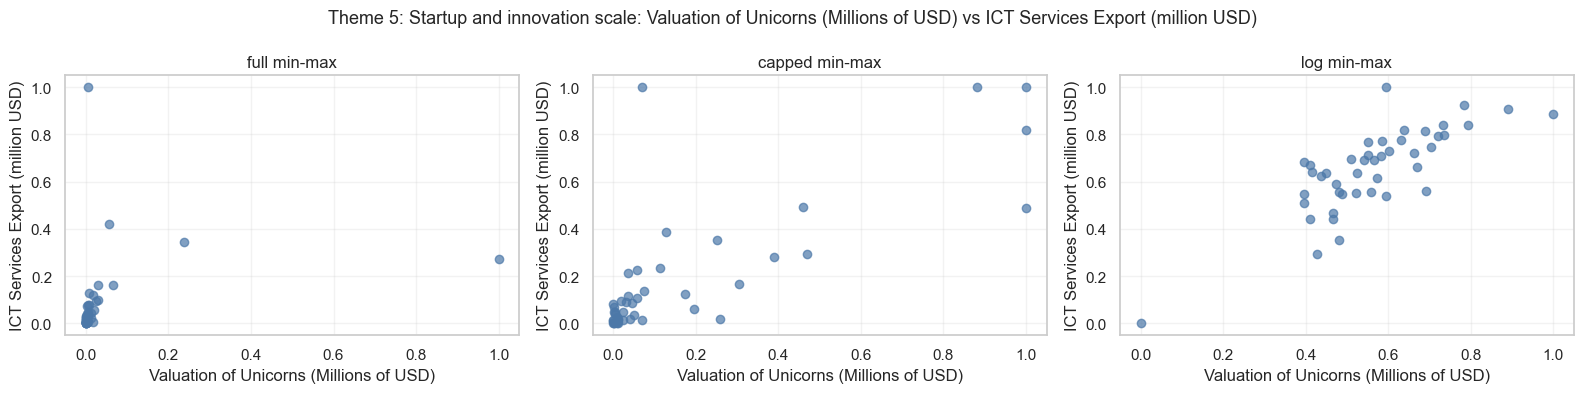


IT market Capitalisation in USD vs Valuation of Unicorns (Millions of USD)
method  n  pearson  spearman
  full 34 0.974362  0.747555
capped 34 0.543114  0.741859
   log 34 0.841556  0.747555


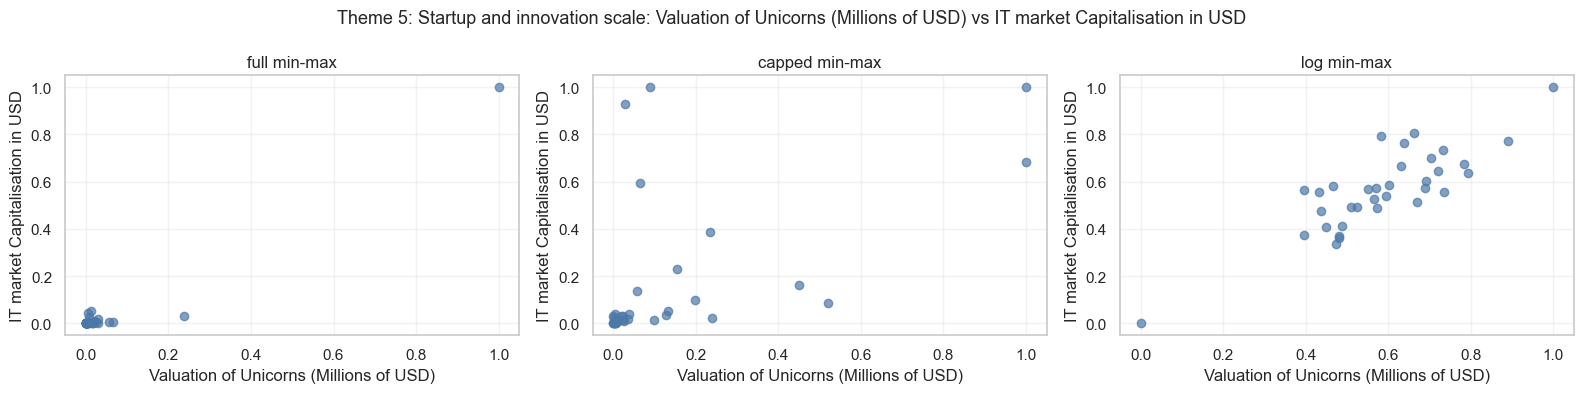

In [15]:
# Theme 5: startup and innovation scale
startup_pairs = [
    ("Number of Start-ups", "VC investments in AI and environmental sustainability by country (USD million)"),
    ("Number of Start-ups", "ICT Services Export (million USD)"),
    ("Number of Start-ups", "IT market Capitalisation in USD"),
    ("Valuation of Unicorns (Millions of USD)", "VC investments in AI and environmental sustainability by country (USD million)"),
    ("Valuation of Unicorns (Millions of USD)", "ICT Services Export (million USD)"),
    ("Valuation of Unicorns (Millions of USD)", "IT market Capitalisation in USD"),
]
run_theme(
    "Theme 5: Startup and innovation scale",
    "This block tests whether startup proliferation and unicorn valuation are linked to broader digital-sector capital and market depth.",
    startup_pairs,
)

## What to look for in the results

A strong Spearman correlation suggests that the variables tend to move together in a consistent rank-based way, which is often more meaningful for skewed country-level indicators than a very high Pearson value alone.

In practice, the most useful story for the report will usually come from relationships that are:
- strong and stable across the three scaling methods, and
- meaningful in economic or policy terms rather than only statistically large.

If one transformation produces a very different result from the others, that usually means the relationship is being driven by a small number of outliers and should be interpreted cautiously.